# Start and end node Flow Trees

For use in Figure 6.

Table of Contents:
1. Imports and load data
2. Make node Flow Trees
3. Plot node Flow Trees
4. Compare object vs. non-object

## 1. Imports and load data

In [45]:
import karateclub as kc
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import warnings
import seaborn as sns

from scipy import stats
from sklearn.decomposition import PCA

from flow_tree_utils import OBJECTS, load_test_df, collapse_traj, compute_extended_explore_traj, compute_explore_traj, generate_trajs_from_df, generate_traj_from_path, generate_flow_tree_from_trajs, plot_flow_tree

warnings.filterwarnings("ignore")
pd.options.mode.chained_assignment = None

# Load test data into dataframe
test_df = load_test_df()

## 2. Make node Flow Trees

### Start-node Flow Trees

In [24]:
## Make node trees for everything
# Create empty DataFrame to store all tree information
all_tree_df = pd.DataFrame(columns=[
    'node',           # the actual node label
    'trees'           # list of bootstrapped trees
])
example_tree_by_start_node = {}

def process_path(path):
    states = path.split()
    states[-1] = "."+states[-1]
    states = collapse_traj(states)
    return(states)

trajs = [process_path(x) for x in test_df["paths"]]
traj_dict = {x: [] for x in "ABCDEFGHIJKLMNOPQRSTUVWXYZ"}

for traj in trajs:
    for i in range(len(traj)-8): # want min path length 4/5
        traj_dict[traj[i]].append(traj[i:i+7])

k_fold = 20
for node in traj_dict:
    trees = []
    for _ in range(k_fold):
        sampled_trajs = traj_dict[node]
        if len(sampled_trajs) > 17:
            sampled_indices = np.random.choice(len(sampled_trajs), size=18, replace=False)
            sampled_trajs = [sampled_trajs[i] for i in sampled_indices]
        else:
            print(len(sampled_trajs))
        G = generate_flow_tree_from_trajs(sampled_trajs, END_NODE="1")
        new_G = nx.relabel.convert_node_labels_to_integers(G, first_label=0, ordering='default')
        trees.append(new_G)
        
    example_tree_by_start_node[node] = trees[0]

    all_tree_df = pd.concat([all_tree_df, pd.DataFrame({
        'node': [(node,)] * len(trees), 
        'trees': trees
    })], ignore_index=True)

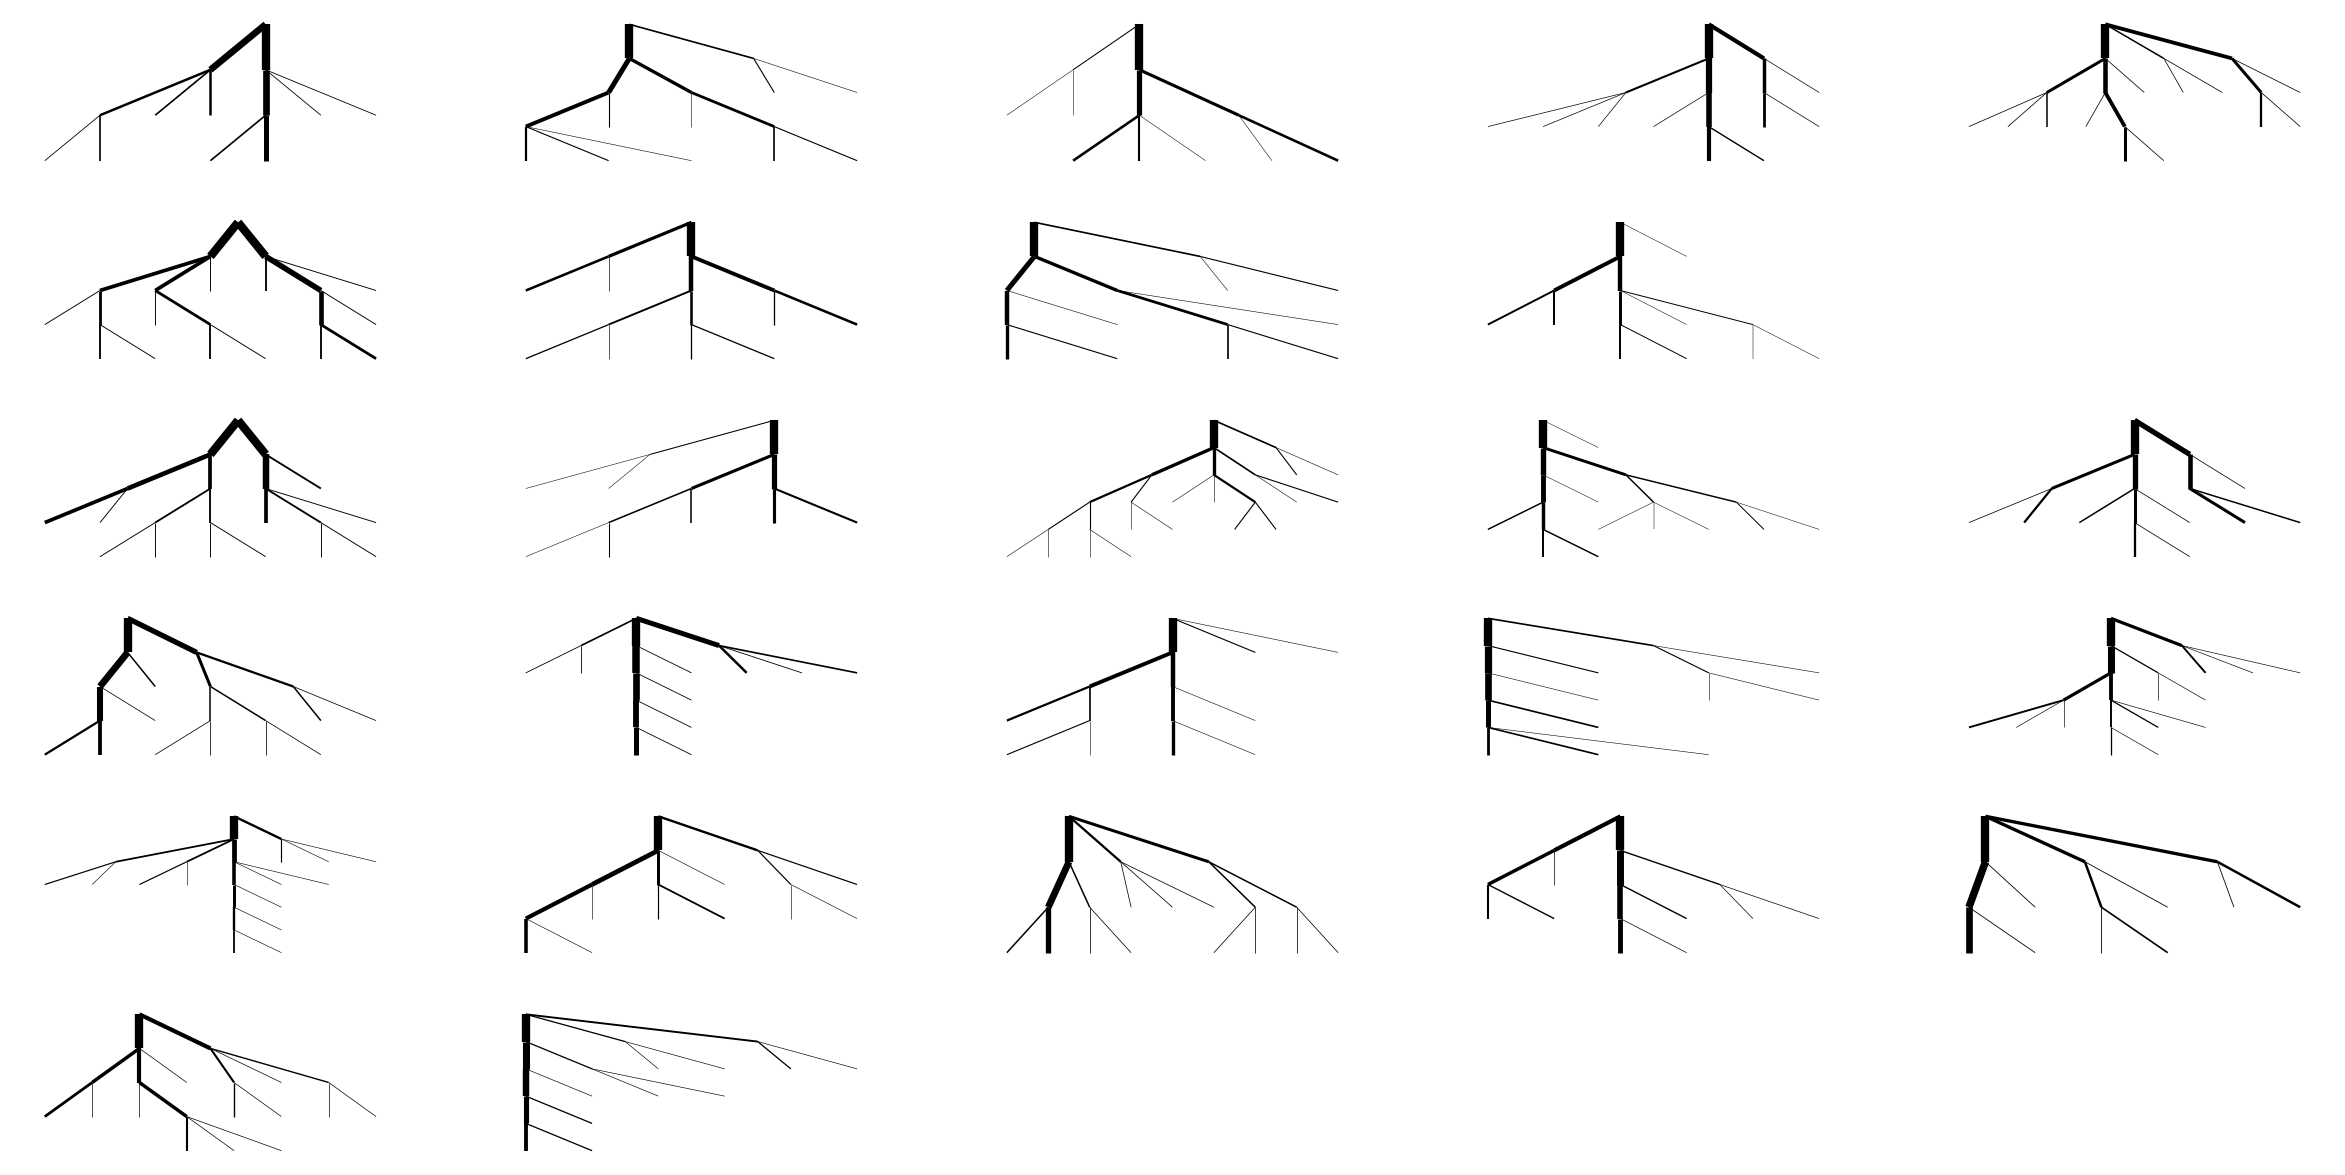

In [98]:
nodes_by_degree = {1: OBJECTS, 2: "BFSZV", 3: "CDEGHJMQXTU", 4: "R"}
nodes_by_obj = {1: OBJECTS, 2: "BFSZV"+"CDEGHJMQXTU"+"R"}

# print(len("".join([nodes_by_degree[n] for n  in nodes_by_degree])))

fig, axes = plt.subplots(6, 5, figsize=(30,15))

row = -1
for n in nodes_by_obj:
    # row += 1
    for i, node in enumerate(nodes_by_obj[n]):
        if i % 5 == 0:
            row += 1

        G = example_tree_by_start_node[node]
        ax = axes[row][i % 5]
        plot_flow_tree(G, f"Start at {node}", ax, just_edges=True, no_title=True)

        

# i = 0
# for node in example_tree_by_start_node:
#     if node in OBJECTS: continue
#     G = example_tree_by_start_node[node]
#     # print(f"{i} -> row={i // 3}, col={(i % 6) + 3}")
#     ax = axes[i // 6][((i % 6) + 3)]
#     plot_flow_tree(G, f"Start at {node}", ax, just_edges=True, no_title=True)
#     i += 1

# fig.suptitle("Start-node Flow Trees")
for ax in axes.ravel():
    ax.set_axis_off()

plt.show()

#### helper fns

In [109]:
def get_heaviest_path(tree, root):    
    # Get all leaves (nodes with degree 1, excluding the root)
    leaves = [node for node in tree.nodes() if tree.degree(node) == 1 and node != root]
    # leaves = [node for node in tree.nodes() if tree.nodes[node].get("color", "white") in ["yellow", "green"]]

    def dfs(node, current_path, current_weight):
        nonlocal max_weight, heaviest_path
        
        # If we're at a leaf (degree 1 and not root)
        if node in leaves:
            if current_weight > max_weight:
                max_weight = current_weight
                heaviest_path = current_path.copy()
            return
            
        # Explore all children
        for neighbor in tree.neighbors(node):
            if neighbor not in current_path:  # Avoid cycles
                edge_weight = tree[node][neighbor]['weight']
                current_path.append(neighbor)
                dfs(neighbor, current_path, current_weight + edge_weight)
                current_path.pop()
    
    max_weight = float('-inf')
    heaviest_path = None
    dfs(root, [root], 0)
    
    return heaviest_path, max_weight, [tree[heaviest_path[i]][heaviest_path[i+1]]['weight'] for i in range(len(heaviest_path)-1)]

def extract_tree_features(graph, root):
    # Number of Nodes
    num_nodes = graph.number_of_nodes()
    
    # Tree Depth (Height)
    def tree_depth(graph, root):
        depths = nx.single_source_shortest_path_length(graph, root)
        return max(depths.values())
    
    depth = tree_depth(graph, root)
    
    # Diameter
    diameter = nx.diameter(graph)

    backbone_path, max_weight, weights = get_heaviest_path(graph, root)
    backbone_thickness = np.mean(weights) / max_weight
    
    # Number of Leaves
    num_leaves = sum(1 for node in graph.nodes() if graph.degree(node) == 1)
    
    # Branching Factor
    branching_factors = [len(list(graph.neighbors(node))) for node in graph.nodes()]
    avg_branching_factor = np.mean(branching_factors)
    
    # Put all features in a list
    feature_names = ['num_nodes', 'depth', 'diameter', 'num_leaves', 'avg_branching', 'backbone_thickness']
    features = np.array([
        num_nodes,
        depth,
        diameter,
        num_leaves,
        avg_branching_factor,
        backbone_thickness
    ])
    
    return feature_names, features

#### Node flow tree features

In [111]:
# Extract features for each tree
all_feature_names = None
all_features = []

for tree in all_tree_df["trees"]:
    # Get root node (any node with no incoming edges)
    root = 0
    
    # Extract features for this tree
    feature_names, features = extract_tree_features(tree, root)
    
    # Store feature names once
    if all_feature_names is None:
        all_feature_names = feature_names
        
    all_features.append(features)

# Convert to numpy array
tree_features = np.array(all_features)

# Add feature columns to dataframe
for i, name in enumerate(all_feature_names):
    all_tree_df[f"feature_{name}"] = tree_features[:,i]

num_nodes
Mann-Whitney U test p-value: 0.0000
21104.0

Object num_nodes:
Mean: 16.2722
Variance: 15.2315

Non-object num_nodes:
Mean: 18.6059
Variance: 16.5270


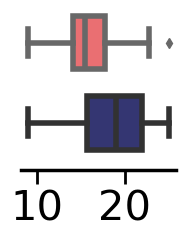

num_leaves
Mann-Whitney U test p-value: 0.0000
20882.5

Object num_leaves:
Mean: 9.2056
Variance: 4.7189

Non-object num_leaves:
Mean: 10.5235
Variance: 5.1259


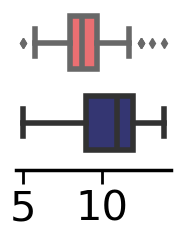

depth
Mann-Whitney U test p-value: 0.0000
22412.5

Object depth:
Mean: 3.9056
Variance: 0.4189

Non-object depth:
Mean: 4.2941
Variance: 0.5664


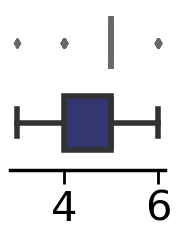

diameter
Mann-Whitney U test p-value: 0.0000
21987.0

Object diameter:
Mean: 6.5833
Variance: 1.4097

Non-object diameter:
Mean: 7.1941
Variance: 1.3153


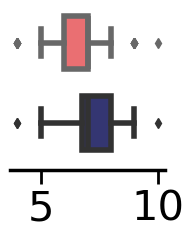

avg_branching
Mann-Whitney U test p-value: 0.0000
21104.0

Object avg_branching:
Mean: 1.8686
Variance: 0.0015

Non-object avg_branching:
Mean: 1.8871
Variance: 0.0007


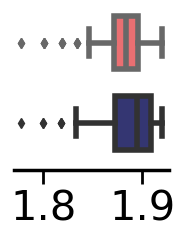

backbone_thickness
Mann-Whitney U test p-value: 0.0000
38929.5

Object backbone_thickness:
Mean: 0.2829
Variance: 0.0038

Non-object backbone_thickness:
Mean: 0.2598
Variance: 0.0057


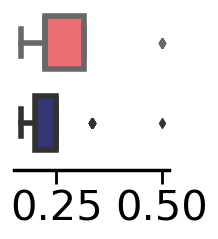

In [112]:
from matplotlib.gridspec import GridSpec


degree_order = "".join([nodes_by_degree[n] for n  in nodes_by_degree])

for fn in ["num_nodes", "num_leaves", "depth", "diameter", "avg_branching", "backbone_thickness"]:
    feature = f"feature_{fn}"
    print(fn)

    # Split nodes into OBJECTS and non-OBJECTS
    object_features = []
    nonobject_features = []
    for node in degree_order:
        node_trees = all_tree_df[all_tree_df['node'] == (node,)]
        fts = node_trees[feature]
        
        if node in OBJECTS:
            object_features.extend(fts)
        else:
            nonobject_features.extend(fts)

    # Perform statistical test
    stat, pval = stats.mannwhitneyu(object_features, nonobject_features)
    print(f"Mann-Whitney U test p-value: {pval:.4f}")
    print(stat)
    # Print mean and variance for each group
    print(f"\nObject {fn}:")
    print(f"Mean: {np.mean(object_features):.4f}")
    print(f"Variance: {np.var(object_features):.4f}")

    print(f"\nNon-object {fn}:") 
    print(f"Mean: {np.mean(nonobject_features):.4f}")
    print(f"Variance: {np.var(nonobject_features):.4f}")

    # Set up figure and grid
    fig = plt.figure(figsize=(2, 4))  # Wider figure to accommodate 9 subplots
    gs = GridSpec(4, 1, figure=fig)#, height_ratios=[2,2,2,2,2,2,2,2,2,.2], hspace=.5)  # 1 row, 9 columns


    # Store diameters for plotting
    all_features = []
    for deg in nodes_by_obj:
        temp = []
        for node in nodes_by_degree[deg]:
            node_trees = all_tree_df[all_tree_df['node'] == (node,)]
            temp.extend(node_trees[feature])
        all_features.append(temp)


    COLORS = ["#FF5A5F", "#2a2d7c"]
    for i, node in enumerate(nodes_by_obj):
        ax = fig.add_subplot(gs[i])

        sns.boxplot(all_features[i], orient='h', color=COLORS[i], linewidth=4, ax=ax)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_visible(False)
        ax.spines["bottom"].set_visible(False)
        ax.yaxis.set_visible(False)
        ax.xaxis.set_visible(False)
        
        ax.patch.set_visible(False)
        ax.set_facecolor('none') 


    ax.xaxis.set_visible(True)

    ax.spines["bottom"].set_visible(True)
    ax.spines["bottom"].set_linewidth(2.5)
    ax.spines['bottom'].set_position(('outward', 10))

    ax.tick_params(axis='both', which='major', labelsize=30, width=2, length=10)
    # plt.xticks([0, 5, 10])
    plt.xlabel("")

    plt.show()

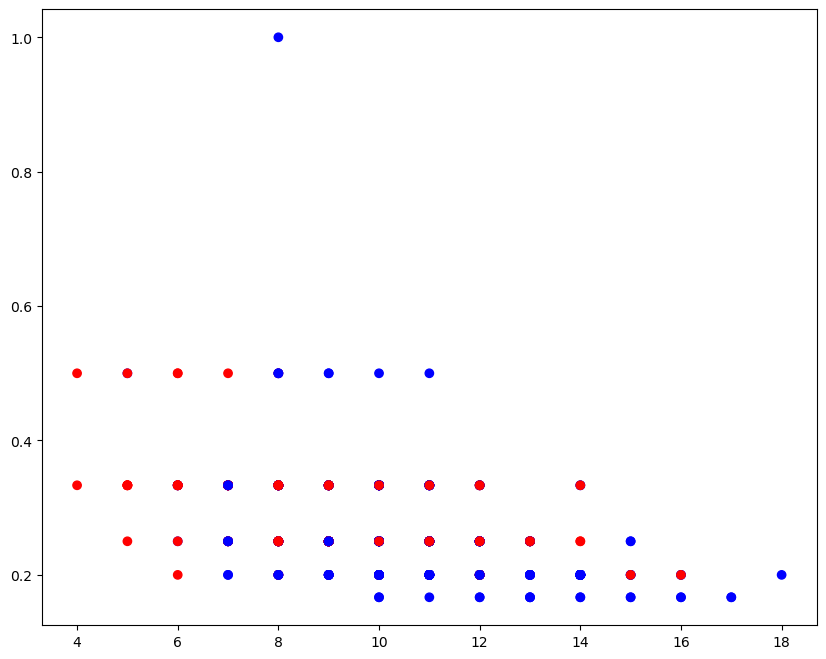

PearsonRResult(statistic=-0.4728591963399017, pvalue=2.510368317355208e-30)

In [113]:
plt.figure(figsize=(10,8))
# print(pca_result[:,0].shape)
# print(len(diameters))
# scatter = plt.scatter(pca_result[:,0], all_tree_df["feature_avg_branching"], 
#                      c=[1 if n in OBJECTS else 0 for n in all_tree_df["node"].str[0]], 
#                      cmap='bwr')
scatter = plt.scatter(all_tree_df['feature_num_leaves'], all_tree_df['feature_backbone_thickness'], 
                     c=[1 if n in OBJECTS else 0 for n in all_tree_df["node"].str[0]], 
                     cmap='bwr')

plt.show()

stats.pearsonr(all_tree_df['feature_num_leaves'], all_tree_df["feature_backbone_thickness"])

In [114]:
node_flow_tree_embedder = kc.Graph2Vec(dimensions=64)
node_flow_tree_embedder.fit(np.array(all_tree_df["trees"]))

# Extract features for each tree
all_embeddings = []

# Get embeddings for each tree
all_tree_embeddings = node_flow_tree_embedder.infer(np.array(all_tree_df["trees"]))

# Add single column with full embedding vector
all_tree_df["embedding"] = [emb for emb in all_tree_embeddings]

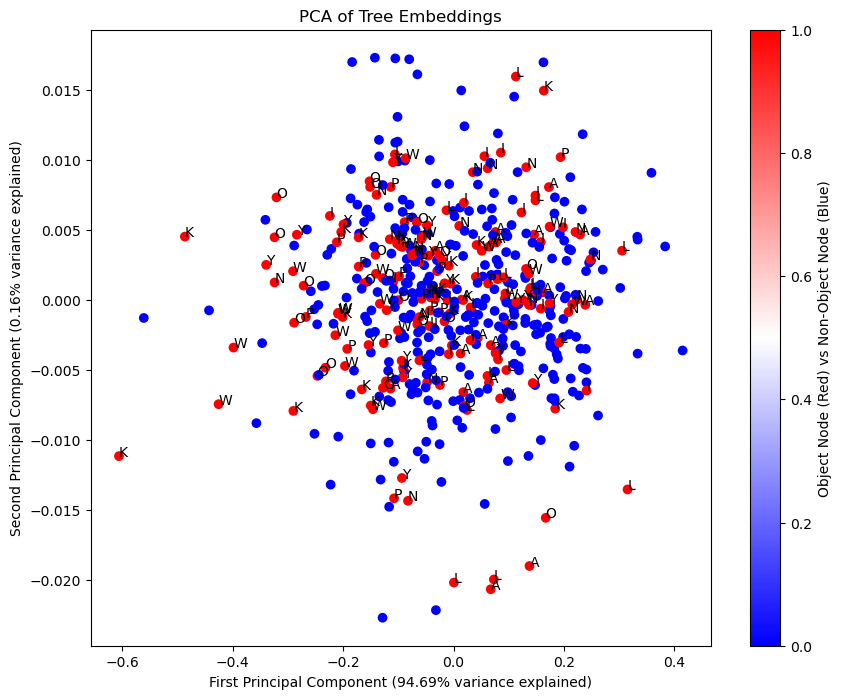


First Principal Component:
26525.0
Mann-Whitney U test p-value: 1.243e-02
Significantly different

Means:
Object nodes PC1: -0.026
Non-object nodes PC1: 0.014
Object nodes PC2: 0.000
Non-object nodes PC2: -0.000

Standard Deviations:
Object nodes PC1: 0.156
Non-object nodes PC1: 0.148
Object nodes PC2: 0.006
Non-object nodes PC2: 0.006

Second Principal Component:
Mann-Whitney U test p-value: 2.834e-01
Not significantly different


In [115]:

# Convert embeddings to a matrix for PCA
embedding_matrix = np.array(all_tree_df["embedding"].tolist())

# Perform PCA
pca = PCA(n_components=4)
pca_result = pca.fit_transform(embedding_matrix)

# Create scatter plot
plt.figure(figsize=(10,8))
scatter = plt.scatter(pca_result[:,0], pca_result[:,1], 
                     c=[1 if n in OBJECTS else 0 for n in all_tree_df["node"].str[0]], 
                     cmap='bwr')

# Add labels for object nodes
for idx, row in all_tree_df.iterrows():
    if row["node"][0] in OBJECTS:
        plt.annotate(row["node"][0], (pca_result[idx,0], pca_result[idx,1]))

plt.title('PCA of Tree Embeddings')
plt.xlabel(f'First Principal Component ({pca.explained_variance_ratio_[0]:.2%} variance explained)')
plt.ylabel(f'Second Principal Component ({pca.explained_variance_ratio_[1]:.2%} variance explained)')
plt.colorbar(scatter, label='Object Node (Red) vs Non-Object Node (Blue)')
plt.show()

# Separate embeddings for object and non-object nodes
object_embeddings = pca_result[[n[0] in OBJECTS for n in all_tree_df["node"]]]
non_object_embeddings = pca_result[[n[0] not in OBJECTS for n in all_tree_df["node"]]]

# Perform statistical test (Mann-Whitney U test) on both principal components

# Test PC1
stat1, pval1 = stats.mannwhitneyu(object_embeddings[:,0], non_object_embeddings[:,0])
print("\nFirst Principal Component:")
print(stat1)
print(f"Mann-Whitney U test p-value: {pval1:.3e}")
print("Significantly different" if pval1 < 0.05 else "Not significantly different")

# Calculate means and standard deviations for both groups
print("\nMeans:")
print(f"Object nodes PC1: {np.mean(object_embeddings[:,0]):.3f}")
print(f"Non-object nodes PC1: {np.mean(non_object_embeddings[:,0]):.3f}")
print(f"Object nodes PC2: {np.mean(object_embeddings[:,1]):.3f}") 
print(f"Non-object nodes PC2: {np.mean(non_object_embeddings[:,1]):.3f}")

print("\nStandard Deviations:")
print(f"Object nodes PC1: {np.std(object_embeddings[:,0]):.3f}")
print(f"Non-object nodes PC1: {np.std(non_object_embeddings[:,0]):.3f}")
print(f"Object nodes PC2: {np.std(object_embeddings[:,1]):.3f}")
print(f"Non-object nodes PC2: {np.std(non_object_embeddings[:,1]):.3f}")


# Test PC2  
stat2, pval2 = stats.mannwhitneyu(object_embeddings[:,1], non_object_embeddings[:,1])
print("\nSecond Principal Component:")
print(f"Mann-Whitney U test p-value: {pval2:.3e}")
print("Significantly different" if pval2 < 0.05 else "Not significantly different")



## 3. More detail for object start-node

In [116]:
# Create empty DataFrame to store all tree information
tree_df = pd.DataFrame(columns=[
    'node_type',      # 'start' or 'end'
    'node',           # the actual node label
    'trajectory_type', # 'all', 'winner', or 'loser'
    'mean_accuracy',   # mean accuracy for this group
    'trees'           # list of bootstrapped trees
])

ttt = []
# Function to generate bootstrapped trees
def generate_bootstrap_trees(group, k_fold=20, sample_frac=0.7, reverse_trajs=False):
    trees = []
    for _ in range(k_fold):
        sampled_group = group.sample(frac=sample_frac)
        # Randomly select 58 samples if group is larger than that
        if len(sampled_group) > 58:
            sampled_group = sampled_group.sample(n=58)
        trajs = generate_trajs_from_df(sampled_group)
        if reverse_trajs:
            trajs = [list(reversed(t)) for t in trajs]
        ttt.append(len(trajs))
        G = generate_flow_tree_from_trajs(trajs, END_NODE="1")
        new_G = nx.relabel.convert_node_labels_to_integers(G, first_label=0, ordering='default')
        trees.append(new_G)
    return trees

# Generate trees for start nodes
example_tree_by_start_node = {}
for traj_type, df_subset in [
    ('all', test_df),
    ('winner', test_df[test_df['accuracy']]),
    ('loser', test_df[~test_df['accuracy']])
]:
    for start_node, group in df_subset.groupby(['StartAt']):
        mean_acc = np.mean(group['path_mean_acc'])
        trees = generate_bootstrap_trees(group)

        tree_df = pd.concat([tree_df, pd.DataFrame({
            'node_type': ['start'] * len(trees),
            'node': [start_node] * len(trees), 
            'trajectory_type': [traj_type] * len(trees),
            'mean_accuracy': [mean_acc] * len(trees),
            'trees': trees
        })], ignore_index=True)

# Generate trees for end nodes
test_df['ending_node'] = test_df['paths'].apply(lambda x: x[-1])
for traj_type, df_subset in [
    ('all', test_df),
    ('winner', test_df[test_df['ending_node'] == test_df['EndAt']]),
    ('loser', test_df[test_df['ending_node'] != test_df['EndAt']])
]:
    for end_node, group in df_subset.groupby(['ending_node']):
        if end_node[0] not in OBJECTS:
            continue
        mean_acc = np.mean(group['path_mean_acc'])
        trees = generate_bootstrap_trees(group, reverse_trajs=True)
        
        tree_df = pd.concat([tree_df, pd.DataFrame({
            'node_type': ['end'] * len(trees),
            'node': [end_node] * len(trees),
            'trajectory_type': [traj_type] * len(trees),
            'mean_accuracy': [mean_acc] * len(trees),
            'trees': trees
        })], ignore_index=True)

print(np.mean(ttt))
print(max(ttt), min(ttt))

57.96296296296296
58 56


#### Old w/ start, winner, loser

In [117]:
## BY START
# All trajectories
start_tree_dict = {}
for start_node, group in test_df.groupby(["StartAt"]):
    trajs = generate_trajs_from_df(group)
    G = generate_flow_tree_from_trajs(trajs, END_NODE="1")#end_node)

    new_G = nx.relabel.convert_node_labels_to_integers(G, first_label=0, ordering='default') # need to do for embeddings
    start_tree_dict[start_node] = [new_G, np.mean(group["path_mean_acc"])]

# # Winners only
# start_winner_dict = {}
# for start_node, group in test_df[test_df["accuracy"]].groupby(["StartAt"]):
#     trajs = generate_trajs_from_df(group)
#     G = generate_flow_tree_from_trajs(trajs, END_NODE="1")
#     new_G = nx.relabel.convert_node_labels_to_integers(G, first_label=0, ordering='default')
#     start_winner_dict[start_node] = [new_G, np.mean(group["path_mean_acc"])]

# # Losers only  
# start_loser_dict = {}
# for start_node, group in test_df[~test_df["accuracy"]].groupby(["StartAt"]):
#     trajs = generate_trajs_from_df(group)
#     G = generate_flow_tree_from_trajs(trajs, END_NODE="1")
#     new_G = nx.relabel.convert_node_labels_to_integers(G, first_label=0, ordering='default')
#     start_loser_dict[start_node] = [new_G, np.mean(group["path_mean_acc"])]

dict_keys([('A',), ('I',), ('K',), ('L',), ('N',), ('O',), ('P',), ('W',), ('Y',)])


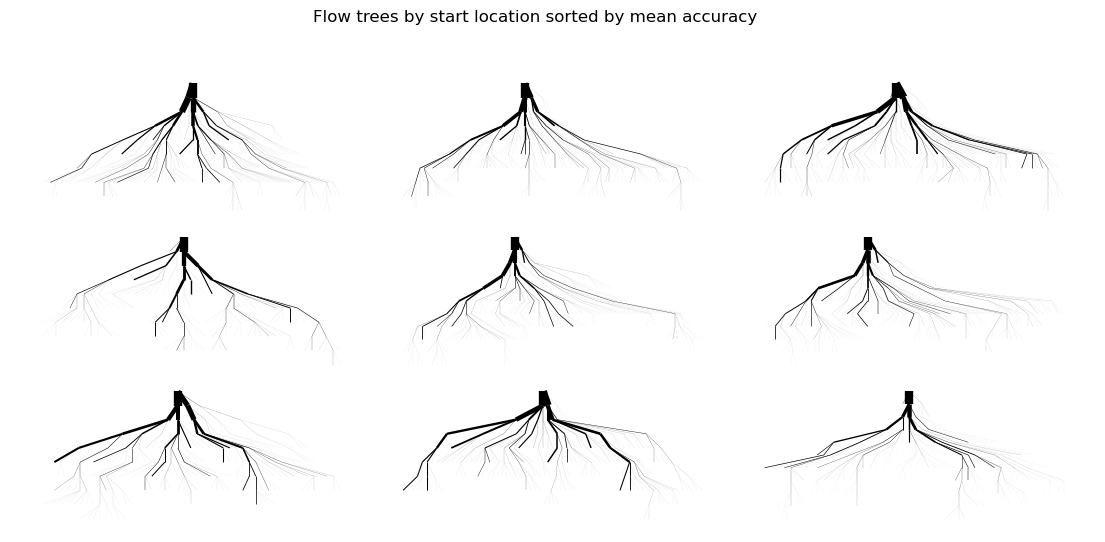

In [118]:
print(start_tree_dict.keys())
# Plot all trajectories
start_accs = [v[1] for v in start_tree_dict.values()]
start_graphs = [v[0] for v in start_tree_dict.values()]
start_nodes = list(start_tree_dict.keys())

fig, axes = plt.subplots(3, 3, figsize=(14,6))
plt.subplots_adjust(wspace=0, hspace=0)  # Remove spacing between subplots
sorted_order = [x for x in sorted(range(len(start_accs)), key=lambda x: start_accs[x])]
for i, tree_index in enumerate(sorted_order):
    G = start_graphs[tree_index]
    ax = axes[i // 3][i % 3]
    plot_flow_tree(G, "", ax, just_edges=True)  # Removed title from individual plots
fig.suptitle("Flow trees by start location sorted by mean accuracy")
fig.savefig("figures/start_flow_trees_by_acc.png")
plt.show()

# # Plot winners
# start_winner_accs = [v[1] for v in start_winner_dict.values()]
# start_winner_graphs = [v[0] for v in start_winner_dict.values()]
# start_winner_nodes = list(start_winner_dict.keys())

# fig, axes = plt.subplots(3, 3, figsize=(20,10))
# # sorted_order = [x for x in sorted(range(len(start_winner_accs)), key=lambda x: start_winner_accs[x])]
# for i, tree_index in enumerate(sorted_order):
#     G = start_winner_graphs[tree_index]
#     ax = axes[i // 3][i % 3]
#     plot_flow_tree(G, f"Start at {start_winner_nodes[tree_index]} {start_winner_accs[tree_index]:.2f}", ax, just_edges=True)
# fig.suptitle("WINNERS ONLY: Flow trees by start location sorted by mean accuracy") 
# fig.savefig("figures/start_flow_trees_by_acc-winners.png")
# plt.show()

# # Plot losers
# start_loser_accs = [v[1] for v in start_loser_dict.values()]
# start_loser_graphs = [v[0] for v in start_loser_dict.values()]
# start_loser_nodes = list(start_loser_dict.keys())

# fig, axes = plt.subplots(3, 3, figsize=(20,10))
# # sorted_order = [x for x in sorted(range(len(start_loser_accs)), key=lambda x: start_loser_accs[x])]
# for i, tree_index in enumerate(sorted_order):
#     G = start_loser_graphs[tree_index]
#     ax = axes[i // 3][i % 3]
#     plot_flow_tree(G, f"Start at {start_loser_nodes[tree_index]} {start_loser_accs[tree_index]:.2f}", ax, just_edges=True)
# fig.suptitle("LOSERS ONLY: Flow trees by start location sorted by mean accuracy")
# fig.savefig("figures/start_flow_trees_by_acc-losers.png")
# plt.show()

### End-node Flow Trees

In [119]:
## BY END
test_df["ending_node"] = test_df["paths"].apply(lambda x: x[-1])

# All trajectories
end_tree_dict = {}
for end_node, group in test_df.groupby(["ending_node"]):    
    if end_node[0] not in OBJECTS: continue
    
    trajs = generate_trajs_from_df(group)
    rev_trajs = [list(reversed(t)) for t in trajs]
    G = generate_flow_tree_from_trajs(rev_trajs, END_NODE="1")#end_node)

    new_G = nx.relabel.convert_node_labels_to_integers(G, first_label=0, ordering='default') # need to do for embeddings
    end_tree_dict[end_node] = [new_G, np.mean(group["path_mean_acc"])]

# Intentional/winner only
end_winner_dict = {}
for end_node, group in test_df[(test_df["ending_node"] == test_df["EndAt"])].groupby(["ending_node"]):    
    if end_node[0] not in OBJECTS: continue
    
    trajs = generate_trajs_from_df(group)
    rev_trajs = [list(reversed(t)) for t in trajs]
    G = generate_flow_tree_from_trajs(rev_trajs, END_NODE="1")#end_node)

    new_G = nx.relabel.convert_node_labels_to_integers(G, first_label=0, ordering='default') # need to do for embeddings
    end_winner_dict[end_node] = [new_G, np.mean(group["path_mean_acc"])]

# Unintentional/losers only  # Intentional/winner only
end_loser_dict = {}
for end_node, group in test_df[~(test_df["ending_node"] == test_df["EndAt"])].groupby(["ending_node"]):    
    if end_node[0] not in OBJECTS: continue
    
    trajs = generate_trajs_from_df(group)
    rev_trajs = [list(reversed(t)) for t in trajs]
    G = generate_flow_tree_from_trajs(rev_trajs, END_NODE="1")#end_node)

    new_G = nx.relabel.convert_node_labels_to_integers(G, first_label=0, ordering='default') # need to do for embeddings
    end_loser_dict[end_node] = [new_G, np.mean(group["path_mean_acc"])]

### Plot End-node Flow Trees

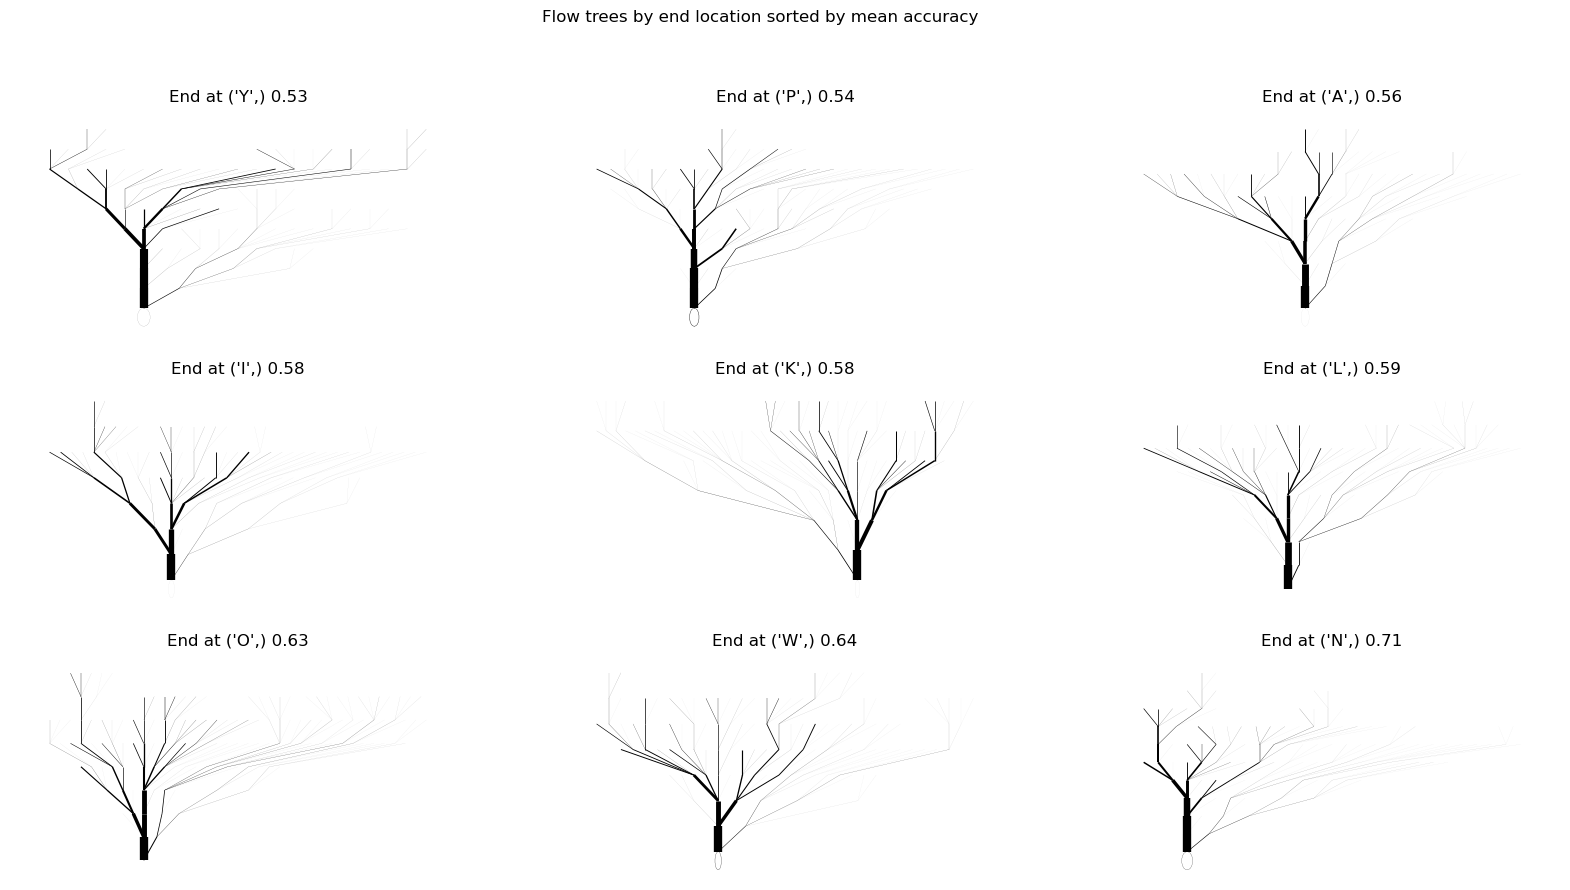

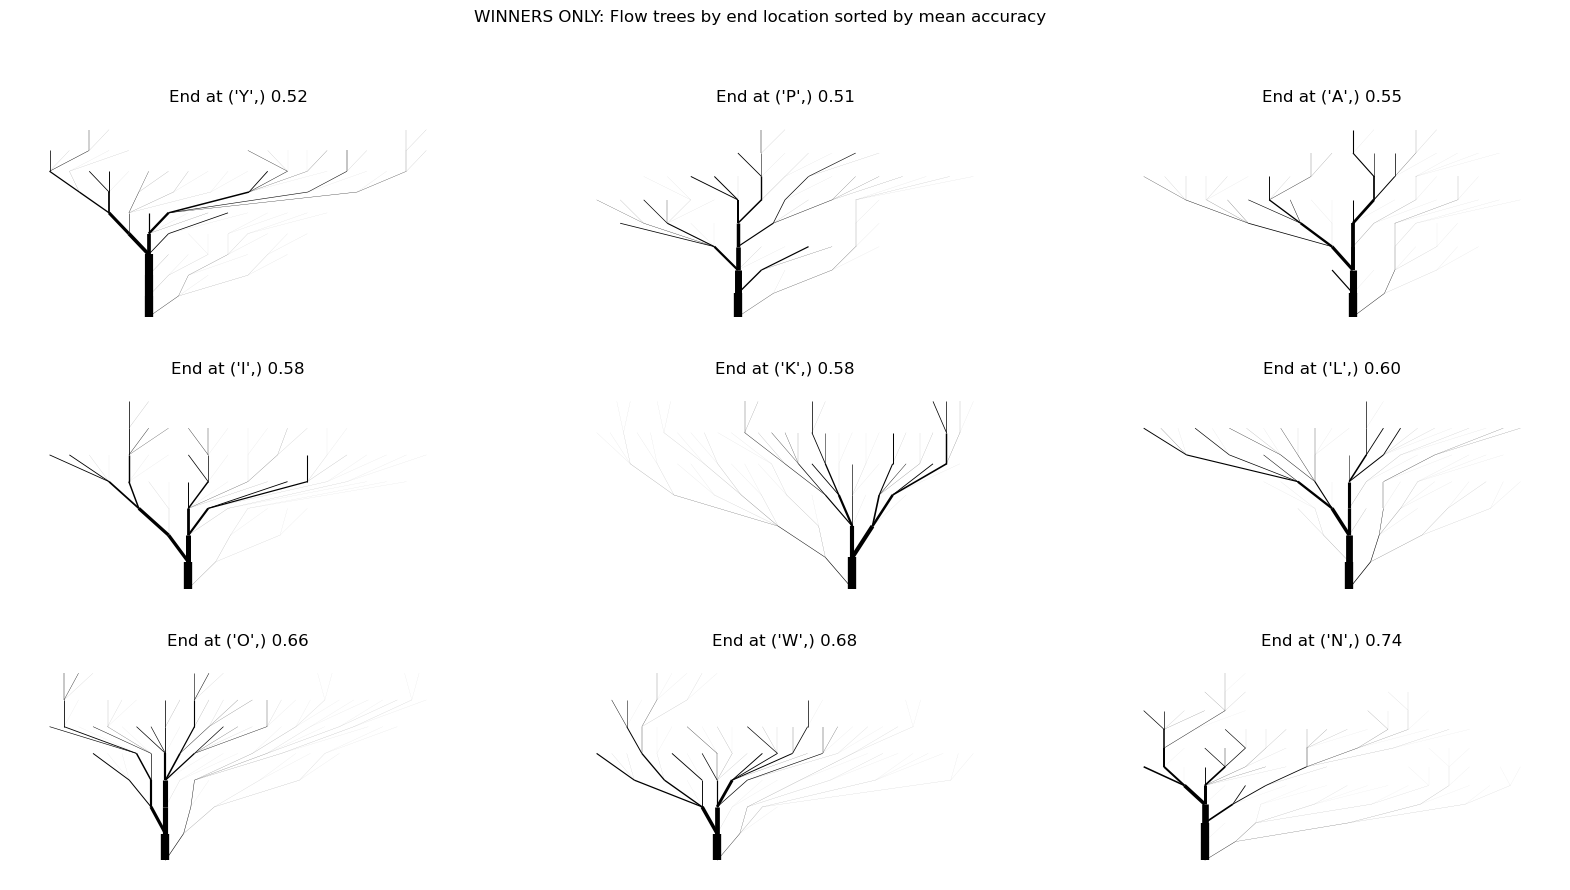

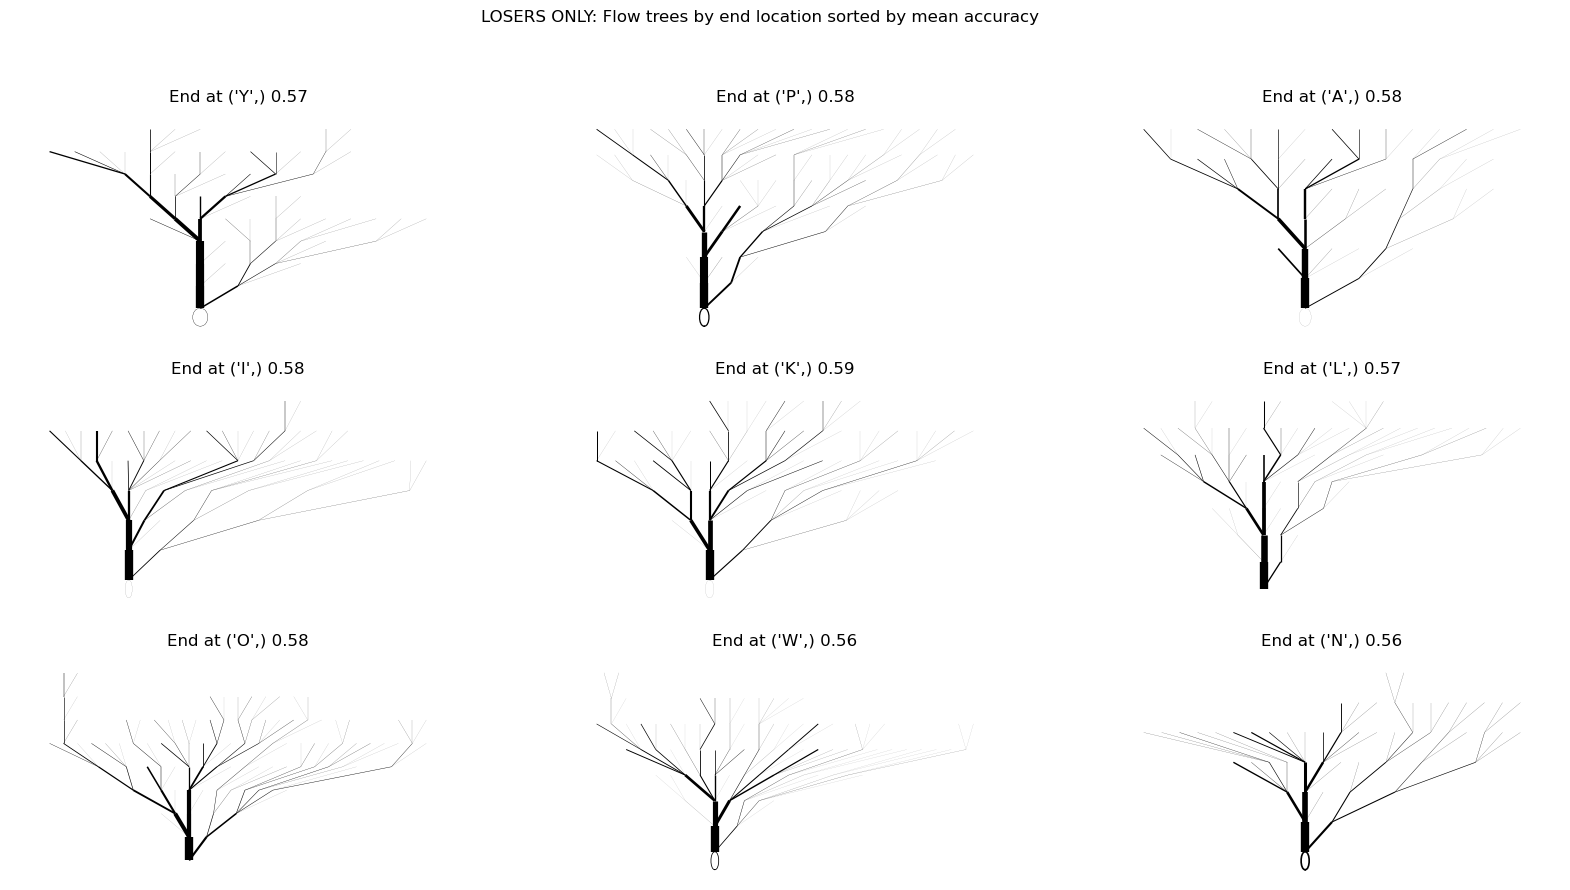

In [120]:
# Plot all trajectories
end_accs = [v[1] for v in end_tree_dict.values()]
end_graphs = [v[0] for v in end_tree_dict.values()]
end_nodes = list(end_tree_dict.keys())

fig, axes = plt.subplots(3, 3, figsize=(20,10))
sorted_order = [x for x in sorted(range(len(end_accs)), key=lambda x: end_accs[x])]
for i, tree_index in enumerate(sorted_order):
    G = end_graphs[tree_index]
    ax = axes[i // 3][i % 3]
    ax.invert_yaxis() # Flip y-axis
    plot_flow_tree(G, f"End at {end_nodes[tree_index]} {end_accs[tree_index]:.2f}", ax, just_edges=True)
fig.suptitle("Flow trees by end location sorted by mean accuracy")
fig.savefig("figures/end_flow_trees_by_acc.png")
plt.show()

# Plot winners
end_winner_accs = [v[1] for v in end_winner_dict.values()]
end_winner_graphs = [v[0] for v in end_winner_dict.values()]
end_winner_nodes = list(end_winner_dict.keys())

fig, axes = plt.subplots(3, 3, figsize=(20,10))
# sorted_order = [x for x in sorted(range(len(end_winner_accs)), key=lambda x: end_winner_accs[x])]
for i, tree_index in enumerate(sorted_order):
    G = end_winner_graphs[tree_index]
    ax = axes[i // 3][i % 3]
    ax.invert_yaxis() # Flip y-axis
    plot_flow_tree(G, f"End at {end_winner_nodes[tree_index]} {end_winner_accs[tree_index]:.2f}", ax, just_edges=True)
fig.suptitle("WINNERS ONLY: Flow trees by end location sorted by mean accuracy") 
fig.savefig("figures/end_flow_trees_by_acc-winners.png")
plt.show()

# Plot losers
end_loser_accs = [v[1] for v in end_loser_dict.values()]
end_loser_graphs = [v[0] for v in end_loser_dict.values()]
end_loser_nodes = list(end_loser_dict.keys())

fig, axes = plt.subplots(3, 3, figsize=(20,10))
# sorted_order = [x for x in sorted(range(len(end_loser_accs)), key=lambda x: end_loser_accs[x])]
for i, tree_index in enumerate(sorted_order):
    G = end_loser_graphs[tree_index]
    ax = axes[i // 3][i % 3]
    ax.invert_yaxis() # Flip y-axis
    plot_flow_tree(G, f"End at {end_loser_nodes[tree_index]} {end_loser_accs[tree_index]:.2f}", ax, just_edges=True)
fig.suptitle("LOSERS ONLY: Flow trees by end location sorted by mean accuracy")
fig.savefig("figures/end_flow_trees_by_acc-losers.png")
plt.show()


# canyou gather people's intention from here? like look at subtrees and cluster???
# real human movement

## 22. Object Start v Rev End Flow Tree

In [141]:
## Make node trees for everything
# Create empty DataFrame to store all tree information
all_tree_df = pd.DataFrame(columns=[
    "node",           # the actual node label
    "trees",           # list of bootstrapped trees
    "reverse"
])

def process_path(path):
    states = path.split()
    states[-1] = "."+states[-1]
    states = collapse_traj(states)
    return(states)

trajs = [process_path(x) for x in test_df["paths"]]
traj_dict = {x: [] for x in "ABCDEFGHIJKLMNOPQRSTUVWXYZ"}

for traj in trajs:
    for i in range(len(traj)-8): # want min path length 4/5
        traj_dict[traj[i]].append(traj[i:i+7])

s_example_tree_by_start_node = {}
r_example_tree_by_start_node = {}

k_fold = 20
for node in OBJECTS:
    # START NODE FLOW TREES
    trees = []
    for _ in range(k_fold):
        sampled_trajs = traj_dict[node]
        if len(sampled_trajs) > 17:
            sampled_indices = np.random.choice(len(sampled_trajs), size=18, replace=False)
            sampled_trajs = [sampled_trajs[i] for i in sampled_indices]
        else:
            print(len(sampled_trajs))
        G = generate_flow_tree_from_trajs(sampled_trajs, END_NODE="1")
        new_G = nx.relabel.convert_node_labels_to_integers(G, first_label=0, ordering='default')
        trees.append(new_G)
        
    s_example_tree_by_start_node[node] = trees[0]

    all_tree_df = pd.concat([all_tree_df, pd.DataFrame({
        'node': [(node,)] * len(trees), 
        'trees': trees,
        "reverse": False
    })], ignore_index=True)

    # REV END NODE FLOW TREES
    group = test_df[test_df["ending_node"] == node]
    trajs = generate_trajs_from_df(group)
    rev_trajs = [list(reversed(t))[:7] for t in trajs]

    trees = []
    for _ in range(k_fold):
        sampled_trajs = rev_trajs
        if len(sampled_trajs) > 17:
            sampled_indices = np.random.choice(len(sampled_trajs), size=18, replace=False)
            sampled_trajs = [sampled_trajs[i] for i in sampled_indices]
        else:
            print(len(sampled_trajs))

        G = generate_flow_tree_from_trajs(sampled_trajs, END_NODE="1")
        new_G = nx.relabel.convert_node_labels_to_integers(G, first_label=0, ordering='default')
        trees.append(new_G)

    r_example_tree_by_start_node[node] = trees[0]

    all_tree_df = pd.concat([all_tree_df, pd.DataFrame({
        'node': [(node,)] * len(trees), 
        'trees': trees,
        "reverse": True
    })], ignore_index=True)


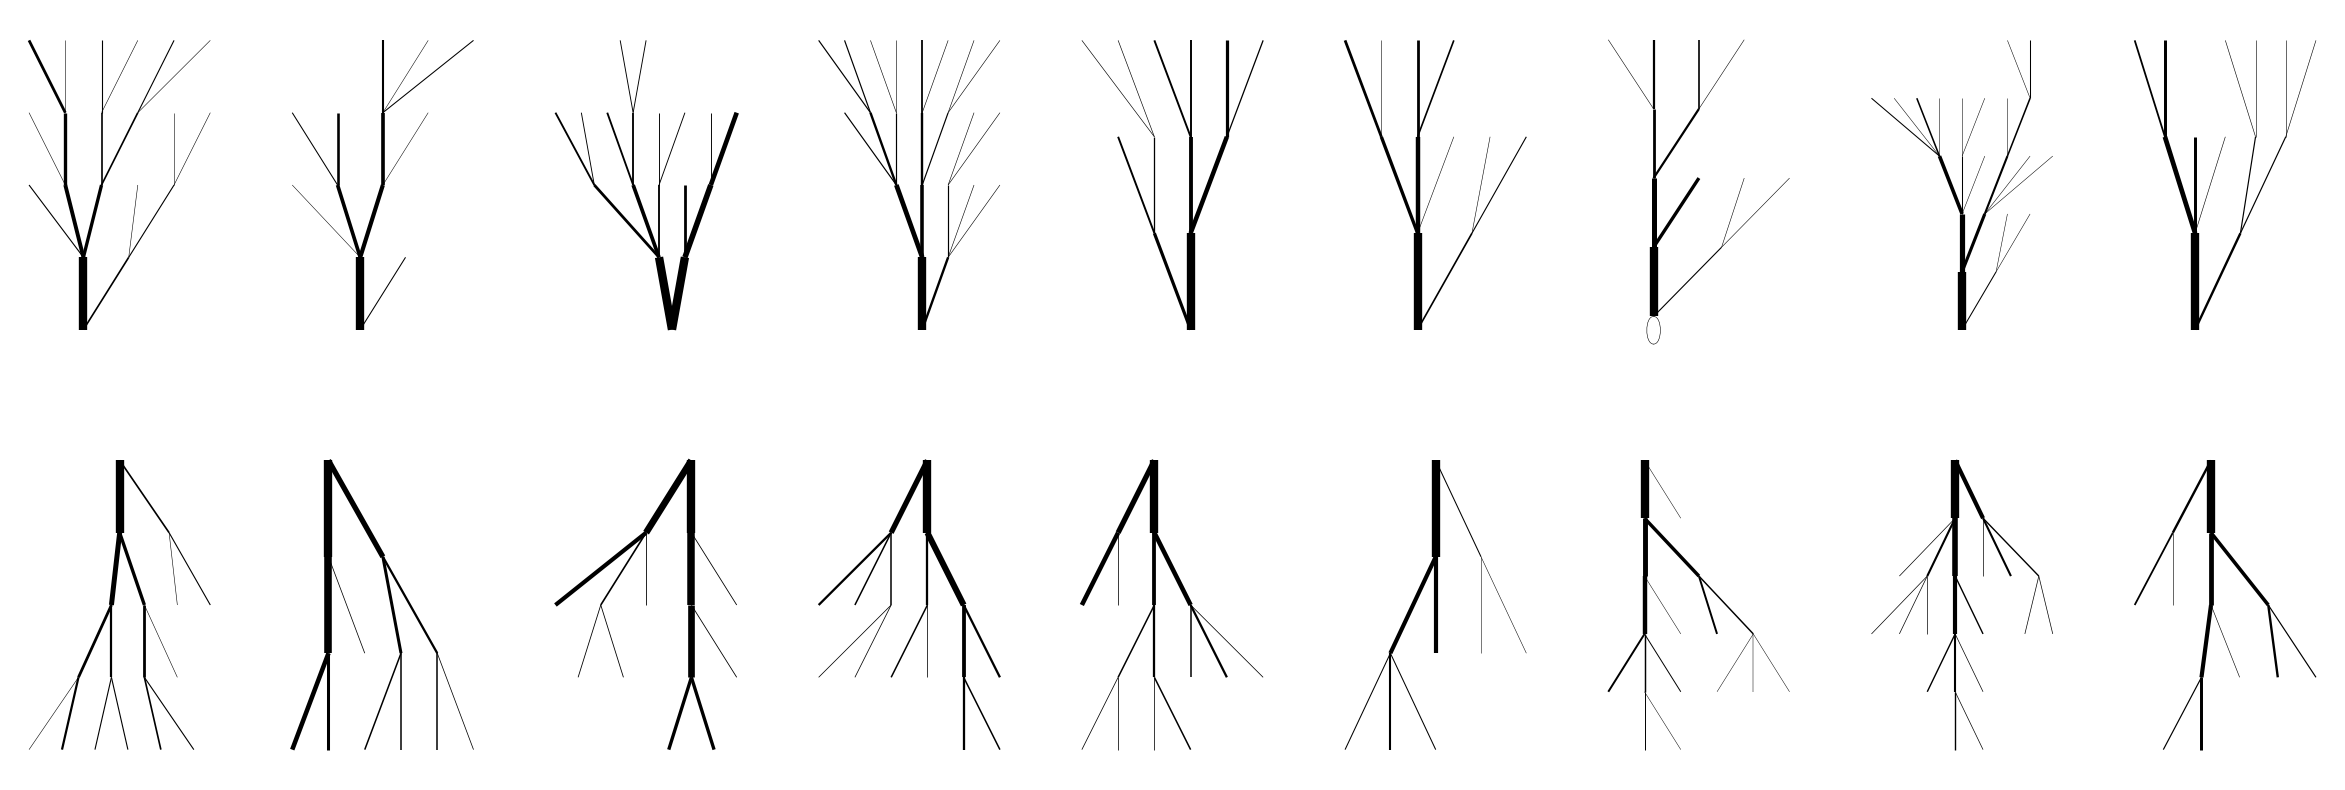

In [146]:
fig, axes = plt.subplots(2, 9, figsize=(30,10))

for i, node in enumerate("ALKOINPWY"):
    G = r_example_tree_by_start_node[node]
    ax = axes[0][i % 9]
    ax.invert_yaxis()
    plot_flow_tree(G, f"Start at {node}", ax, just_edges=True, no_title=True)


for i, node in enumerate("ALKOINPWY"):
    G = s_example_tree_by_start_node[node]
    ax = axes[1][i % 9]
    plot_flow_tree(G, f"Start at {node}", ax, just_edges=True, no_title=True)


        
for ax in axes.ravel():
    ax.set_axis_off()

plt.show()

In [148]:
# Extract features for each tree
all_feature_names = None
all_features = []

for tree in all_tree_df["trees"]:
    # Get root node (any node with no incoming edges)
    root = 0
    
    # Extract features for this tree
    feature_names, features = extract_tree_features(tree, root)
    
    # Store feature names once
    if all_feature_names is None:
        all_feature_names = feature_names
        
    all_features.append(features)

# Convert to numpy array
tree_features = np.array(all_features)

# Add feature columns to dataframe
for i, name in enumerate(all_feature_names):
    all_tree_df[f"feature_{name}"] = tree_features[:,i]

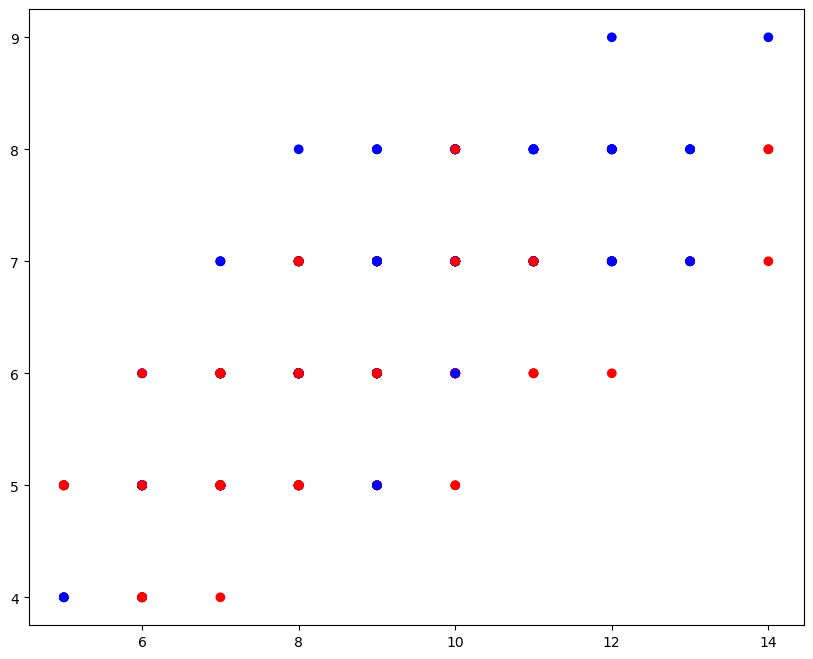

PearsonRResult(statistic=-0.40469935301333626, pvalue=1.2789087959890507e-15)

In [180]:
plt.figure(figsize=(10,8))

scatter = plt.scatter(all_tree_df['feature_num_leaves'], all_tree_df['feature_diameter'], 
                     c=[1 if n else 0 for n in all_tree_df["reverse"]], 
                     cmap='bwr')

plt.show()

stats.pearsonr(all_tree_df['feature_num_leaves'], all_tree_df["feature_backbone_thickness"])

num_nodes
Mann-Whitney U test p-value: 0.0012
19386.0

Start num_nodes:
Mean: 15.8333
Variance: 12.2833

End num_nodes:
Mean: 14.7222
Variance: 11.4340
0 0
[23.0, 16.0, 18.0, 17.0, 16.0, 17.0, 20.0, 22.0, 21.0, 18.0, 18.0, 16.0, 19.0, 19.0, 16.0, 26.0, 14.0, 16.0, 19.0, 19.0]
0 1
[12.0, 13.0, 14.0, 11.0, 14.0, 9.0, 13.0, 15.0, 10.0, 11.0, 15.0, 12.0, 9.0, 11.0, 11.0, 15.0, 12.0, 13.0, 9.0, 15.0]
0 2
[13.0, 13.0, 16.0, 16.0, 16.0, 15.0, 17.0, 12.0, 13.0, 14.0, 14.0, 14.0, 16.0, 15.0, 15.0, 18.0, 14.0, 13.0, 18.0, 14.0]
0 3
[13.0, 17.0, 19.0, 14.0, 15.0, 19.0, 16.0, 10.0, 13.0, 14.0, 14.0, 18.0, 14.0, 12.0, 15.0, 13.0, 10.0, 16.0, 15.0, 18.0]
0 4
[13.0, 11.0, 13.0, 13.0, 14.0, 15.0, 13.0, 17.0, 13.0, 11.0, 15.0, 14.0, 13.0, 13.0, 13.0, 15.0, 9.0, 9.0, 14.0, 13.0]
0 5
[13.0, 13.0, 16.0, 16.0, 20.0, 14.0, 12.0, 17.0, 16.0, 19.0, 15.0, 16.0, 12.0, 19.0, 17.0, 18.0, 17.0, 14.0, 15.0, 13.0]
0 6
[14.0, 19.0, 20.0, 16.0, 17.0, 17.0, 16.0, 11.0, 17.0, 19.0, 18.0, 15.0, 20.0, 17.0, 14.0, 15.0, 13

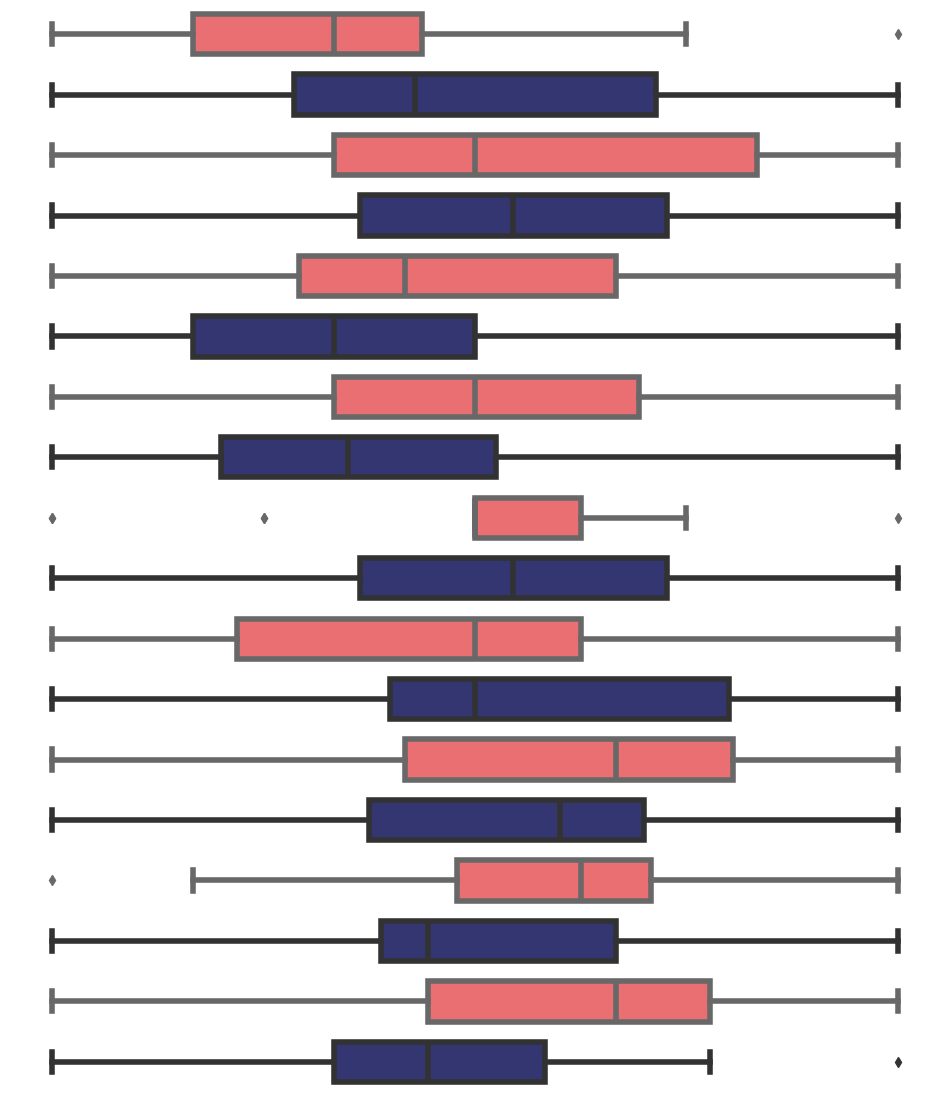

num_leaves
Mann-Whitney U test p-value: 0.0170
18530.0

Start num_leaves:
Mean: 8.9389
Variance: 3.9796

End num_leaves:
Mean: 8.4667
Variance: 3.6044
0 0
[13.0, 9.0, 10.0, 10.0, 9.0, 10.0, 11.0, 12.0, 12.0, 10.0, 10.0, 9.0, 11.0, 11.0, 9.0, 14.0, 8.0, 9.0, 11.0, 10.0]
0 1
[7.0, 7.0, 8.0, 6.0, 8.0, 5.0, 7.0, 8.0, 6.0, 6.0, 8.0, 7.0, 5.0, 6.0, 6.0, 8.0, 7.0, 7.0, 5.0, 8.0]
0 2
[7.0, 7.0, 9.0, 9.0, 9.0, 8.0, 10.0, 7.0, 7.0, 8.0, 8.0, 8.0, 9.0, 8.0, 8.0, 10.0, 8.0, 8.0, 10.0, 8.0]
0 3
[8.0, 10.0, 11.0, 9.0, 9.0, 11.0, 9.0, 6.0, 8.0, 9.0, 8.0, 11.0, 8.0, 7.0, 9.0, 8.0, 6.0, 9.0, 9.0, 10.0]
0 4
[7.0, 6.0, 7.0, 7.0, 8.0, 9.0, 7.0, 10.0, 8.0, 6.0, 8.0, 8.0, 7.0, 7.0, 7.0, 8.0, 5.0, 5.0, 8.0, 7.0]
0 5
[7.0, 7.0, 9.0, 9.0, 11.0, 8.0, 7.0, 9.0, 9.0, 10.0, 8.0, 9.0, 7.0, 10.0, 9.0, 10.0, 10.0, 8.0, 9.0, 7.0]
0 6
[8.0, 10.0, 11.0, 9.0, 10.0, 9.0, 9.0, 7.0, 10.0, 11.0, 10.0, 9.0, 12.0, 10.0, 8.0, 8.0, 8.0, 8.0, 11.0, 10.0]
0 7
[13.0, 11.0, 8.0, 9.0, 10.0, 12.0, 12.0, 12.0, 11.0, 13.0, 11.0, 13.0, 1

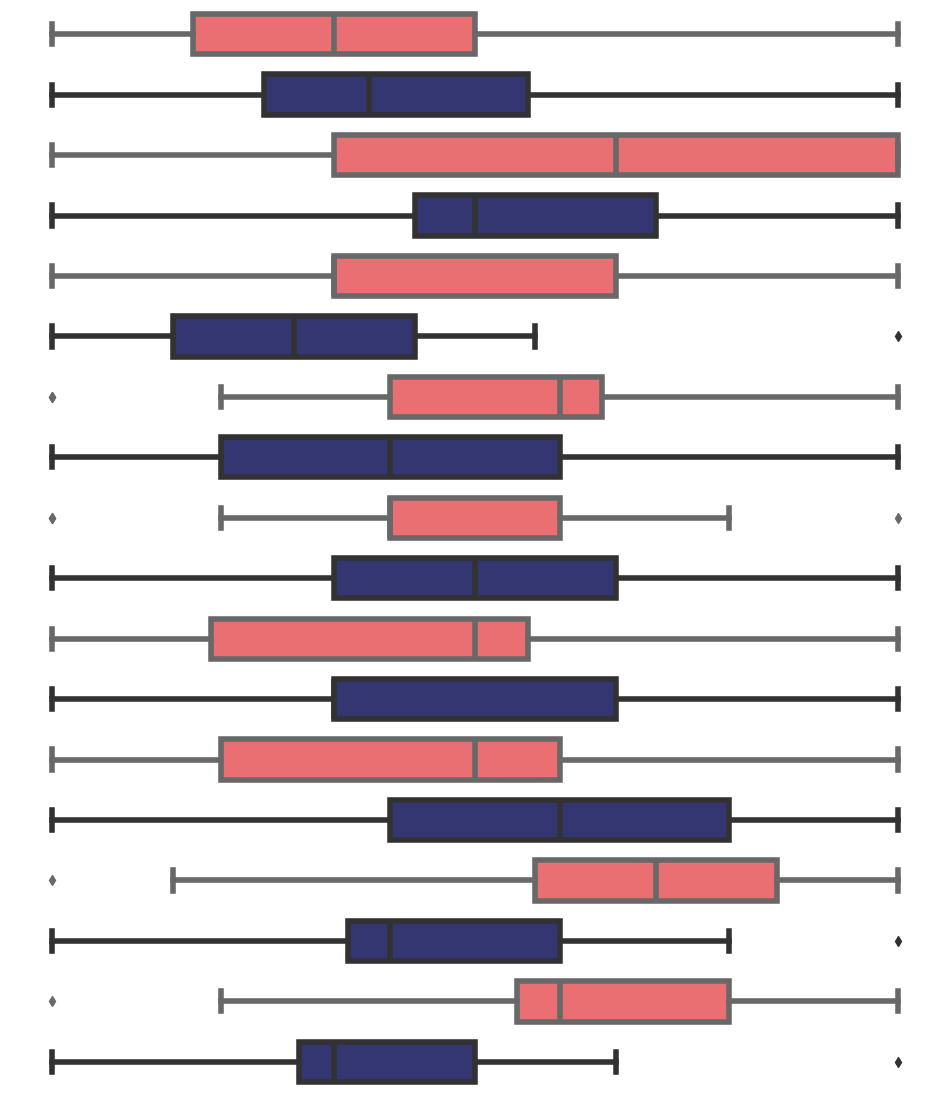

depth
Mann-Whitney U test p-value: 0.6866
16545.0

Start depth:
Mean: 3.8444
Variance: 0.3314

End depth:
Mean: 3.8167
Variance: 0.4164
0 0
[4.0, 4.0, 4.0, 4.0, 4.0, 3.0, 5.0, 5.0, 5.0, 5.0, 4.0, 4.0, 4.0, 5.0, 5.0, 4.0, 4.0, 5.0, 4.0, 5.0]
0 1
[3.0, 4.0, 4.0, 4.0, 4.0, 3.0, 4.0, 4.0, 3.0, 4.0, 5.0, 3.0, 3.0, 4.0, 4.0, 4.0, 3.0, 4.0, 4.0, 4.0]
0 2
[3.0, 3.0, 5.0, 4.0, 4.0, 4.0, 4.0, 4.0, 3.0, 3.0, 4.0, 3.0, 4.0, 4.0, 4.0, 5.0, 4.0, 3.0, 5.0, 3.0]
0 3
[4.0, 3.0, 4.0, 3.0, 4.0, 4.0, 4.0, 3.0, 4.0, 4.0, 5.0, 4.0, 4.0, 4.0, 4.0, 4.0, 3.0, 4.0, 4.0, 4.0]
0 4
[4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0]
0 5
[4.0, 3.0, 4.0, 4.0, 4.0, 3.0, 3.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0]
0 6
[4.0, 4.0, 4.0, 3.0, 4.0, 4.0, 3.0, 3.0, 4.0, 4.0, 4.0, 3.0, 4.0, 4.0, 3.0, 4.0, 4.0, 4.0, 4.0, 4.0]
0 7
[5.0, 4.0, 4.0, 3.0, 3.0, 4.0, 4.0, 4.0, 5.0, 5.0, 4.0, 4.0, 5.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0]
0 8
[4.0, 4.0, 5.0, 4.0,

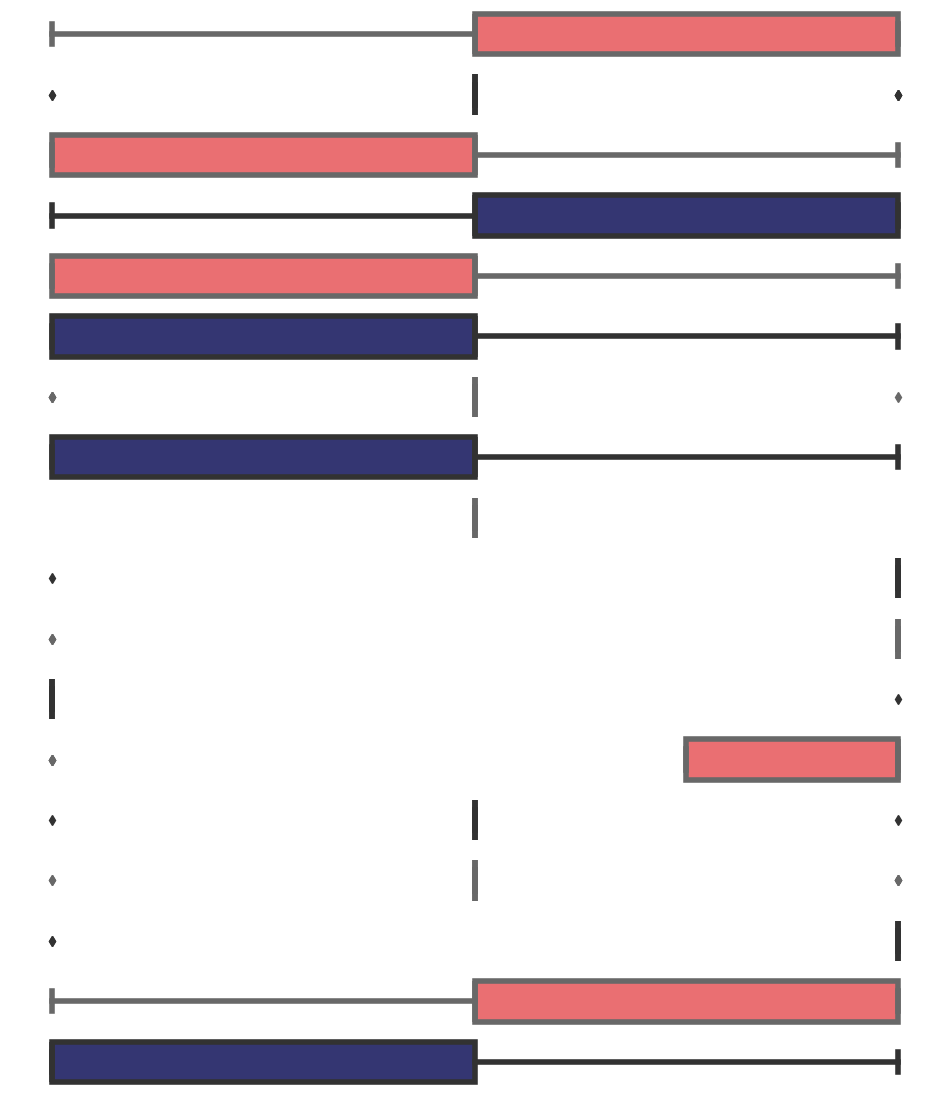

diameter
Mann-Whitney U test p-value: 0.0000
21730.5

Start diameter:
Mean: 6.5333
Variance: 1.1489

End diameter:
Mean: 5.8722
Variance: 0.8226
0 0
[7.0, 6.0, 6.0, 6.0, 6.0, 6.0, 7.0, 7.0, 8.0, 7.0, 7.0, 6.0, 7.0, 7.0, 7.0, 8.0, 7.0, 7.0, 6.0, 7.0]
0 1
[5.0, 6.0, 5.0, 5.0, 6.0, 5.0, 5.0, 6.0, 4.0, 5.0, 7.0, 5.0, 5.0, 5.0, 5.0, 6.0, 5.0, 5.0, 5.0, 6.0]
0 2
[6.0, 6.0, 7.0, 7.0, 7.0, 7.0, 7.0, 5.0, 6.0, 6.0, 6.0, 6.0, 7.0, 7.0, 7.0, 7.0, 6.0, 5.0, 7.0, 6.0]
0 3
[5.0, 6.0, 7.0, 6.0, 6.0, 7.0, 6.0, 5.0, 5.0, 5.0, 7.0, 7.0, 6.0, 5.0, 6.0, 5.0, 4.0, 6.0, 5.0, 6.0]
0 4
[6.0, 5.0, 6.0, 5.0, 6.0, 6.0, 6.0, 7.0, 5.0, 6.0, 7.0, 5.0, 6.0, 6.0, 6.0, 7.0, 5.0, 5.0, 6.0, 5.0]
0 5
[6.0, 6.0, 7.0, 6.0, 7.0, 6.0, 5.0, 6.0, 7.0, 8.0, 7.0, 7.0, 5.0, 8.0, 7.0, 7.0, 7.0, 5.0, 5.0, 6.0]
0 6
[7.0, 8.0, 7.0, 6.0, 7.0, 7.0, 6.0, 5.0, 7.0, 7.0, 7.0, 6.0, 7.0, 7.0, 6.0, 7.0, 6.0, 6.0, 8.0, 7.0]
0 7
[8.0, 7.0, 8.0, 6.0, 6.0, 8.0, 7.0, 8.0, 8.0, 8.0, 8.0, 8.0, 9.0, 7.0, 8.0, 8.0, 7.0, 8.0, 8.0, 7.0]
0 8
[6.0, 5.0, 

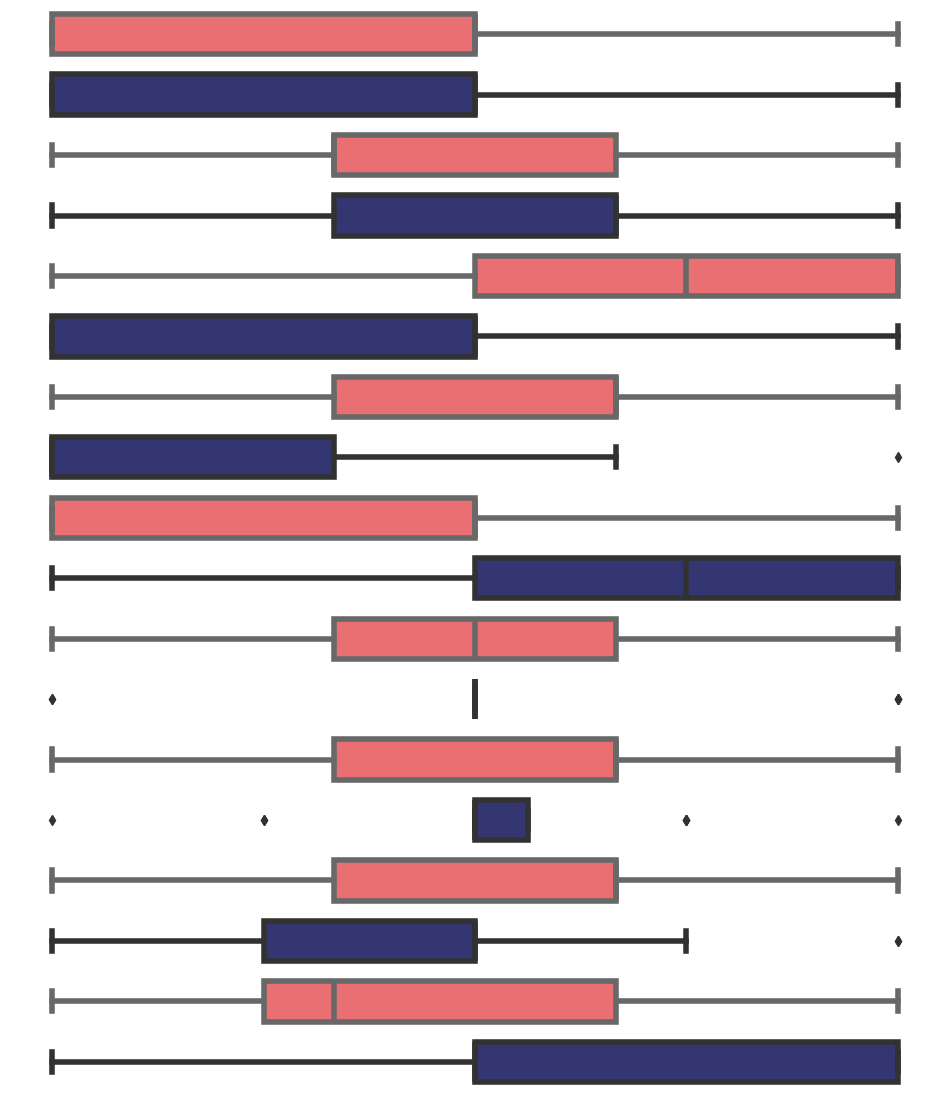

avg_branching
Mann-Whitney U test p-value: 0.4054
15380.5

Start avg_branching:
Mean: 1.8667
Variance: 0.0011

End avg_branching:
Mean: 1.8711
Variance: 0.0014
0 0
[1.9130434782608696, 1.875, 1.8888888888888888, 1.8823529411764706, 1.875, 1.8823529411764706, 1.9, 1.9090909090909092, 1.9047619047619047, 1.8888888888888888, 1.8888888888888888, 1.875, 1.894736842105263, 1.894736842105263, 1.875, 1.9230769230769231, 1.8571428571428572, 1.875, 1.894736842105263, 1.894736842105263]
0 1
[1.8333333333333333, 1.9230769230769231, 1.8571428571428572, 1.8181818181818181, 1.8571428571428572, 1.7777777777777777, 1.8461538461538463, 1.8666666666666667, 1.8, 1.8181818181818181, 1.8666666666666667, 1.8333333333333333, 1.8888888888888888, 1.9090909090909092, 1.8181818181818181, 1.8666666666666667, 1.9166666666666667, 1.8461538461538463, 1.7777777777777777, 1.9333333333333333]
0 2
[1.8461538461538463, 1.8461538461538463, 1.875, 1.875, 1.875, 1.8666666666666667, 1.8823529411764706, 1.8333333333333333, 1.8

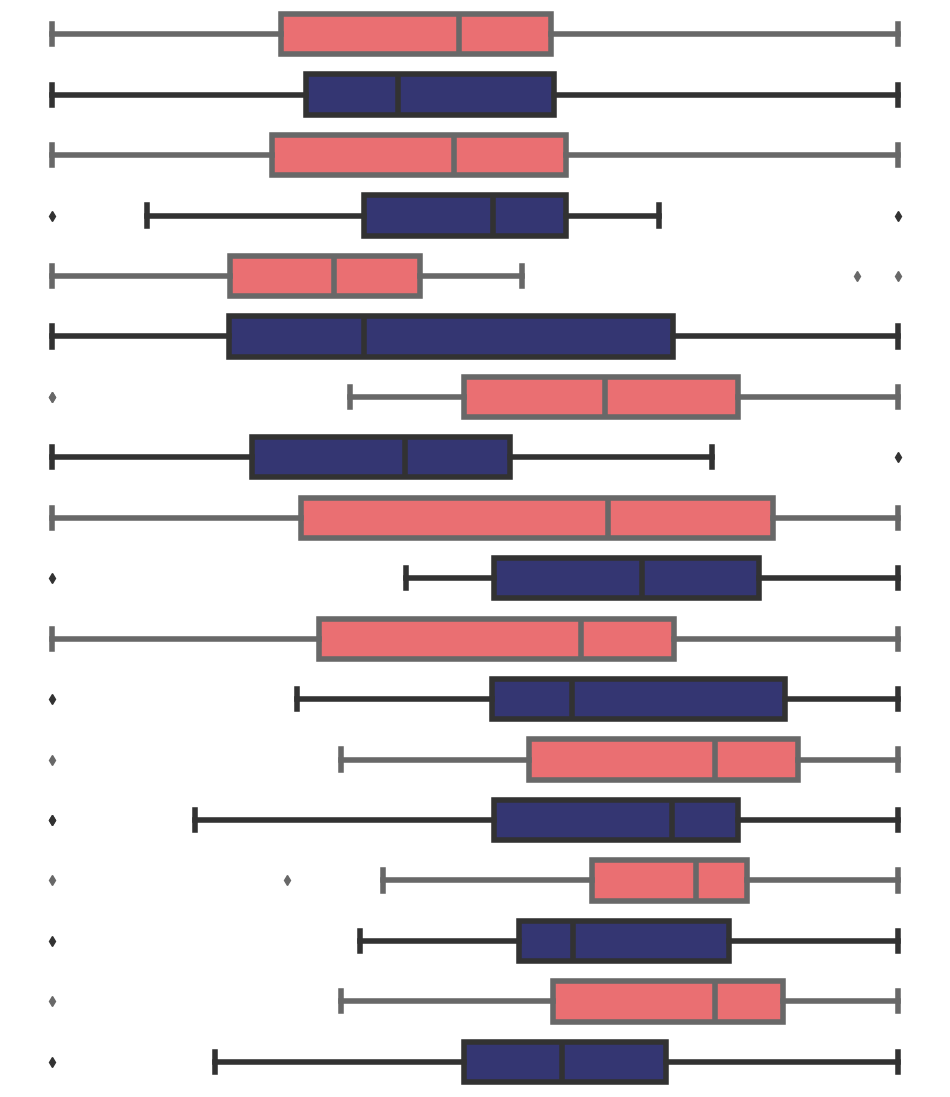

backbone_thickness
Mann-Whitney U test p-value: 0.1000
17681.0

Start backbone_thickness:
Mean: 0.2906
Variance: 0.0034

End backbone_thickness:
Mean: 0.2855
Variance: 0.0043
0 0
[0.25, 0.25, 0.25, 0.25, 0.25, 0.33333333333333337, 0.25, 0.19999999999999998, 0.2, 0.19999999999999998, 0.3333333333333333, 0.25, 0.25, 0.19999999999999998, 0.19999999999999998, 0.25, 0.25, 0.2, 0.25, 0.19999999999999998]
0 1
[0.33333333333333337, 0.25, 0.25, 0.25, 0.25, 0.3333333333333333, 0.25, 0.25, 0.3333333333333333, 0.25, 0.2, 0.33333333333333337, 0.33333333333333337, 0.25, 0.25, 0.25, 0.33333333333333337, 0.25, 0.25, 0.25]
0 2
[0.33333333333333337, 0.3333333333333333, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.3333333333333333, 0.33333333333333337, 0.25, 0.33333333333333337, 0.33333333333333337, 0.3333333333333333, 0.25, 0.25, 0.33333333333333337, 0.3333333333333333, 0.2, 0.5]
0 3
[0.25, 0.3333333333333333, 0.25, 0.3333333333333333, 0.25, 0.25, 0.25, 0.3333333333333333, 0.25, 0.25, 0.2, 0.25, 0.333333333333

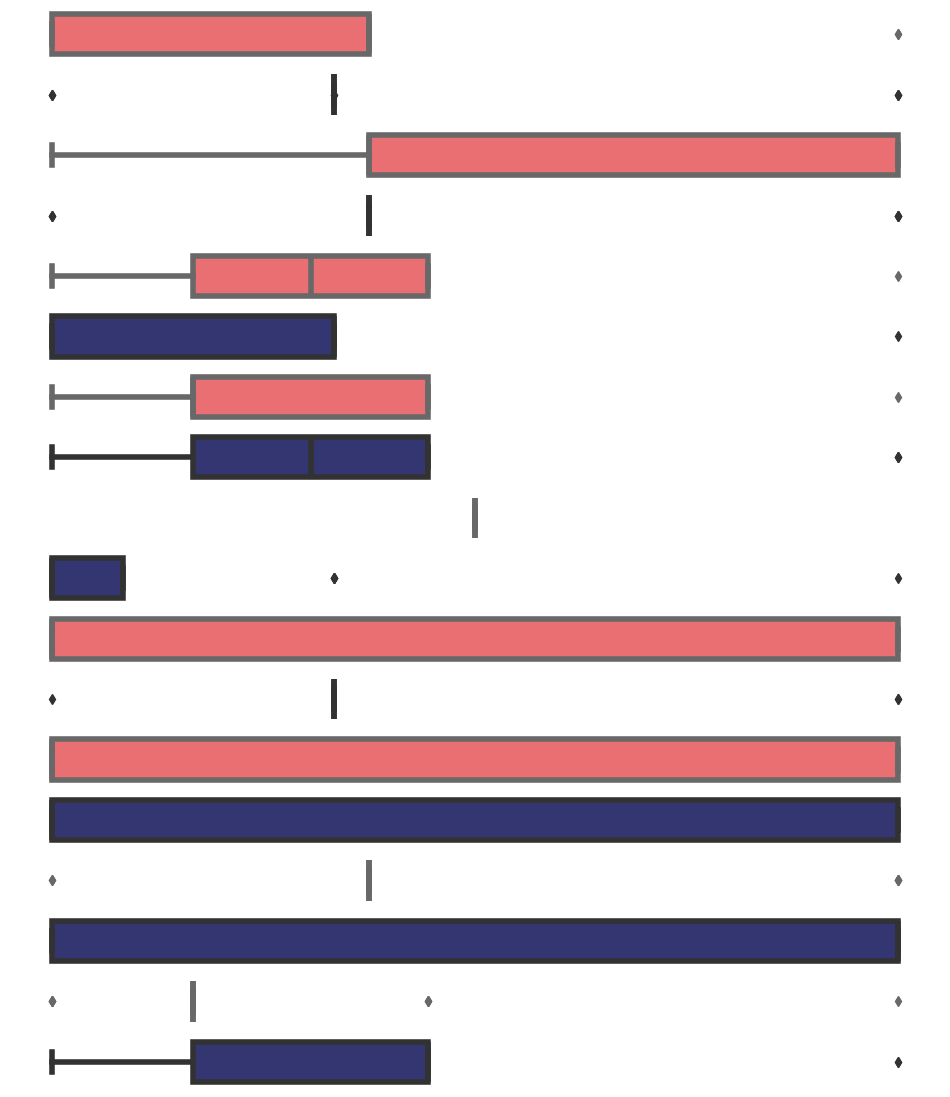

In [178]:
for fn in ["num_nodes", "num_leaves", "depth", "diameter", "avg_branching", "backbone_thickness"]:
    feature = f"feature_{fn}"
    print(fn)

    # Split nodes into OBJECTS and non-OBJECTS
    start_features = []
    end_features = []
    for (node, reverse), group in all_tree_df.groupby(["node", "reverse"]):
        fts = group[feature]

        if reverse:
            end_features.extend(fts)
        else:
            start_features.extend(fts)

    # Perform statistical test
    stat, pval = stats.mannwhitneyu(start_features, end_features)
    print(f"Mann-Whitney U test p-value: {pval:.4f}")
    print(stat)
    # Print mean and variance for each group
    print(f"\nStart {fn}:")
    print(f"Mean: {np.mean(start_features):.4f}")
    print(f"Variance: {np.var(start_features):.4f}")

    print(f"\nEnd {fn}:") 
    print(f"Mean: {np.mean(end_features):.4f}")
    print(f"Variance: {np.var(end_features):.4f}")

    # Set up figure and grid
    fig = plt.figure(figsize=(12, 14))  # Wider figure to accommodate 9 subplots
    gs = GridSpec(18, 1, figure=fig)#, height_ratios=[2,2,2,2,2,2,2,2,2,.2], hspace=.5)  # 1 row, 9 columns


    # Store features for plotting
    all_features = []
    for rev in [True, False]:
        for node in OBJECTS:
            node_trees = all_tree_df[(all_tree_df["reverse"] == rev) & (all_tree_df["node"] == (node,))][feature]
            
            # print(rev, node)
            # print(node_trees)
            # print(all_tree_df)
            all_features.append(node_trees)


    COLORS = ["#FF5A5F", "#2a2d7c"]
    for j, rev in enumerate([True, False]):
        for i, node in enumerate(OBJECTS):
            ax = fig.add_subplot(gs[j+2*i])
            print(j,i)

            # print(all_features[j+2*i])
            print([x for x in all_features[j+2*i]])
            sns.boxplot([x for x in all_features[j+2*i]], orient='v', color=COLORS[j], linewidth=4, ax=ax)

            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
            ax.spines["left"].set_visible(False)
            ax.spines["bottom"].set_visible(False)
            ax.yaxis.set_visible(False)
            ax.xaxis.set_visible(False)
            
            ax.patch.set_visible(False)
            ax.set_facecolor('none') 
            

    # ax.xaxis.set_visible(True)

    # ax.spines["bottom"].set_visible(True)
    # ax.spines["bottom"].set_linewidth(2.5)
    # ax.spines['bottom'].set_position(('outward', 10))

    ax.tick_params(axis='both', which='major', labelsize=30, width=2, length=10)
    # plt.xticks([0, 5, 10])
    plt.xlabel("")
    plt.show()

### STOP HERE?

In [ ]:
# ADD REVERSE ONES

# Generate trees for end nodes
test_df['ending_node'] = test_df['paths'].apply(lambda x: x[-1])
for traj_type, df_subset in [
    ('all', test_df),
    ('winner', test_df[test_df['ending_node'] == test_df['EndAt']]),
    ('loser', test_df[test_df['ending_node'] != test_df['EndAt']])
]:
    for end_node, group in df_subset.groupby(['ending_node']):
        if end_node[0] not in OBJECTS:
            continue
        mean_acc = np.mean(group['path_mean_acc'])
        trees = generate_bootstrap_trees(group, reverse_trajs=True)
        
        tree_df = pd.concat([tree_df, pd.DataFrame({
            'node_type': ['end'] * len(trees),
            'node': [end_node] * len(trees),
            'trajectory_type': [traj_type] * len(trees),
            'mean_accuracy': [mean_acc] * len(trees),
            'trees': trees
        })], ignore_index=True)


## 3. Plot node Flow Trees

## 3b. Generate bootstrapped trees

58.0
58 58


In [122]:
## Make node trees for everything
# Create empty DataFrame to store all tree information
all_tree_df = pd.DataFrame(columns=[
    'node',           # the actual node label
    'trees'           # list of bootstrapped trees
])

def process_path(path):
    states = path.split()
    states[-1] = "."+states[-1]
    states = collapse_traj(states)
    return(states)

trajs = [process_path(x) for x in test_df["paths"]]

traj_dict = {x: [] for x in "ABCDEFGHIJKLMNOPQRSTUVWXYZ"}

for traj in trajs:
    for i in range(len(traj)-8): # want min path length 4/5
        traj_dict[traj[i]].append(traj[i:i+7])

k_fold = 20
for node in traj_dict:
    trees = []
    for _ in range(k_fold):
        sampled_trajs = traj_dict[node]
        if len(sampled_trajs) > 20:
            sampled_indices = np.random.choice(len(sampled_trajs), size=20, replace=False)
            sampled_trajs = [sampled_trajs[i] for i in sampled_indices]
        else:
            print(len(sampled_trajs))
        G = generate_flow_tree_from_trajs(sampled_trajs, END_NODE="1")
        new_G = nx.relabel.convert_node_labels_to_integers(G, first_label=0, ordering='default')
        trees.append(new_G)

    all_tree_df = pd.concat([all_tree_df, pd.DataFrame({
        'node': [(node,)] * len(trees), 
        'trees': trees
    })], ignore_index=True)
# all_tree_df

18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18


## 4. Featurise / embed them

### Tree features

In [123]:




# Extract features for each tree
all_feature_names = None
all_features = []

for tree in tree_df["trees"]:
    # Get root node (any node with no incoming edges)
    root = 0
    
    # Extract features for this tree
    feature_names, features = extract_tree_features(tree, root)
    
    # Store feature names once
    if all_feature_names is None:
        all_feature_names = feature_names
        
    all_features.append(features)

# Convert to numpy array
tree_features = np.array(all_features)

# Add feature columns to dataframe
for i, name in enumerate(all_feature_names):
    tree_df[f"feature_{name}"] = tree_features[:,i]


### Tree embeddings

In [124]:
node_flow_tree_embedder = kc.Graph2Vec(dimensions=64)
node_flow_tree_embedder.fit(np.array(tree_df["trees"]))

# Extract features for each tree
all_embeddings = []

# Get embeddings for each tree
tree_embeddings = node_flow_tree_embedder.infer(np.array(tree_df["trees"]))

# Add single column with full embedding vector
tree_df["embedding"] = [emb for emb in tree_embeddings]

In [ ]:
# # Get all start node winner trees
# start_winners = tree_df[(tree_df['node_type'] == 'start') & (tree_df['trajectory_type'] == 'winner')]

# # Get trees for a specific end node
# node_trees = tree_df[tree_df['node'] == ('A',)]

# # Sort by accuracy
# sorted_trees = tree_df.sort_values('mean_accuracy', ascending=False)


## 5. Cluster them

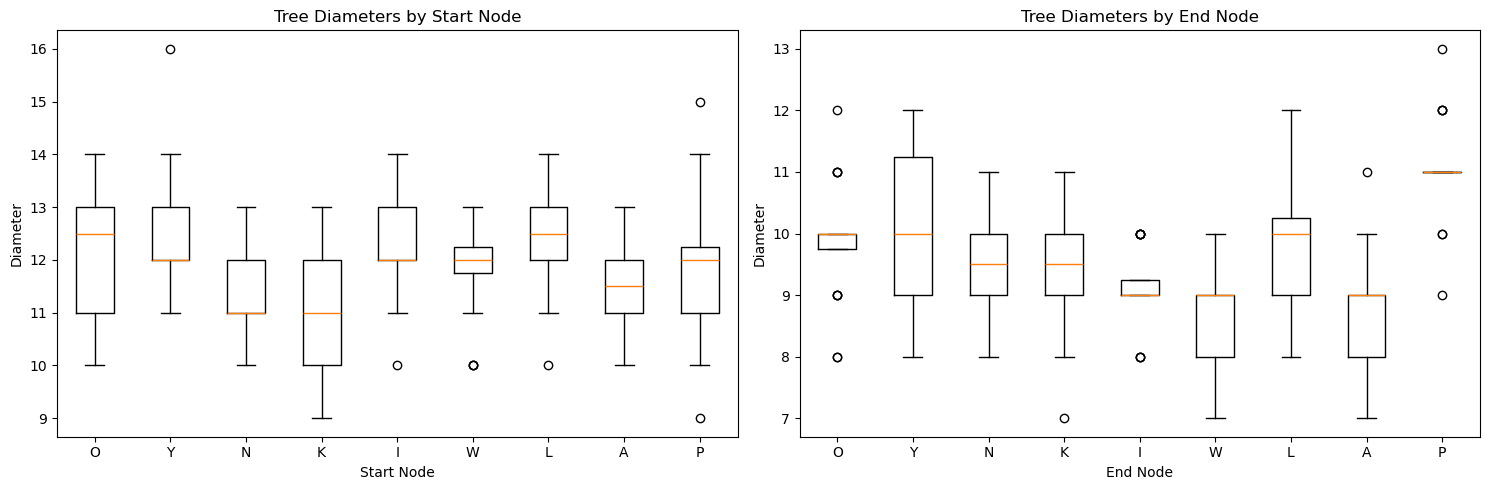

In [125]:
# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot for start nodes
start_trees = tree_df[(tree_df['node_type'] == 'start') & (tree_df["trajectory_type"] == "all")]
start_nodes = start_trees['node'].unique()

start_diameters = []
start_node_labels = []
for node in OBJECTS:
    node = (node,)
    node_trees = start_trees[start_trees['node'] == node]
    diameters = node_trees['feature_diameter']
    start_diameters.append(diameters)
    start_node_labels.extend([str(node[0])] * len(diameters))

ax1.boxplot(start_diameters, labels=[str(n[0]) for n in OBJECTS])
ax1.set_title('Tree Diameters by Start Node')
ax1.set_xlabel('Start Node')
ax1.set_ylabel('Diameter')

# Plot for end nodes 
end_trees = tree_df[(tree_df['node_type'] == 'end') & (tree_df["trajectory_type"] == "all")]
end_nodes = end_trees['node'].unique()

end_diameters = []
end_node_labels = []
for node in OBJECTS:
    node = (node,)
    node_trees = end_trees[end_trees['node'] == node]
    diameters = node_trees['feature_diameter']
    end_diameters.append(diameters)
    end_node_labels.extend([str(node[0])] * len(diameters))

ax2.boxplot(end_diameters, labels=[str(n[0]) for n in OBJECTS])
ax2.set_title('Tree Diameters by End Node')
ax2.set_xlabel('End Node') 
ax2.set_ylabel('Diameter')

plt.tight_layout()
plt.show()
